In [1]:
from matplotlib import pyplot as plt
from src.utils.config import load_config
import pickle
from src.data.dataset import Dataset, decode
from src.model.transformer import Transformer
from src.training.evaluator import Evaluator
from src.utils.transformer_analysis import *
from src.data.dyck_generator import generate_dyck_data
import torch
import torch.nn as nn
import sys
import os
import numpy as np
import random

# Set random seeds.
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # For CUDA reproducibility
np.random.seed(seed)
random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Example analysis

## 1. Load the model and dataset

In [27]:
#=================================
# load your model here by specifying the training timestamp 
#---------------------------------
sesh = 'n13_head1'   # change this to your session name
                     # preloaded ones: n13_head1, n13_head2, n13_head3, n13_head4, decoder
                     
#=================================
# load config
config_path = f'cache/{sesh}/config'
config = load_config(config_path)

# load cached dataset, generate if not exists
batch_size = config['training']['batch_size']
n = config['data']['n']      
data_path = config['data']['data_path']
try:
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Data loaded successfully from {data_path}.")
except FileNotFoundError:
    print(f"Data file not found.")
    generate_dyck_data(n, data_path)
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Data generated and loaded successfully.")
except Exception as e:
    raise Exception(f"Error loading saved data: {e}.")

# load the best trained model from the designated session
model_args = config['model']
if model_args['architecture'] == "decoder_only":
    model_args['max_len'] = (n*2+2)*2 # including BOS and EOS tokens from both input and target sequences
    max_new_tokens = 2*n + 2  # BOS, steps, EOS
else:
    model_args['max_len'] = n*2 + 1  # +1 for BOS token
    # max_new_tokens = model_args['max_len'] - 1  # Exclude BOS token, so -1
    max_new_tokens = n*2  # generate just the steps given BOS in the decoder

# load the datset
if model_args['architecture'] != "decoder_only":
    dataset = Dataset(data,seed=seed,batch_size=batch_size)
else:
    dataset = Dataset(data,seed=seed,batch_size=batch_size,decoder_only=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()      
model = Transformer(**model_args)
model_path = f'cache/{sesh}/best_model.pth'
model.load_state_dict(torch.load(model_path,map_location=torch.device('cpu')))
model.to(device)
model.eval()
print(f"Best model loaded from {sesh}.")

# # Evaluate the model on the validation dataset to see how it performs
# evaluator = Evaluator(model, dataset.eval_dataloader, criterion, device)
# eval_loss_epoch, eval_accuracy_epoch = evaluator.evaluate(max_new_tokens)
# print(f"validation data: loss = {eval_loss_epoch:.4f}, accuracy = {eval_accuracy_epoch:.8f}")

# load analysis examples from the validation dataset
examples = {
    'inputs': dataset.eval_dataloader.dataset.tensors[0].to(device),  # First 5 inputs
    'targets': dataset.eval_dataloader.dataset.tensors[1].to(device)   # First 5 targets
}

Data loaded successfully from data/dyck_data_13.pkl.
Best model loaded from n13_head1.


## 2. Example Usage

### Example 2a. Visualize encoder, decoder self-attention, cross-attention, and Dyck Paths for one example

Input: bos 1 1 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0
Target: bos 1 1 1 1 1 0 1 1 1 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0
predit: bos 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0


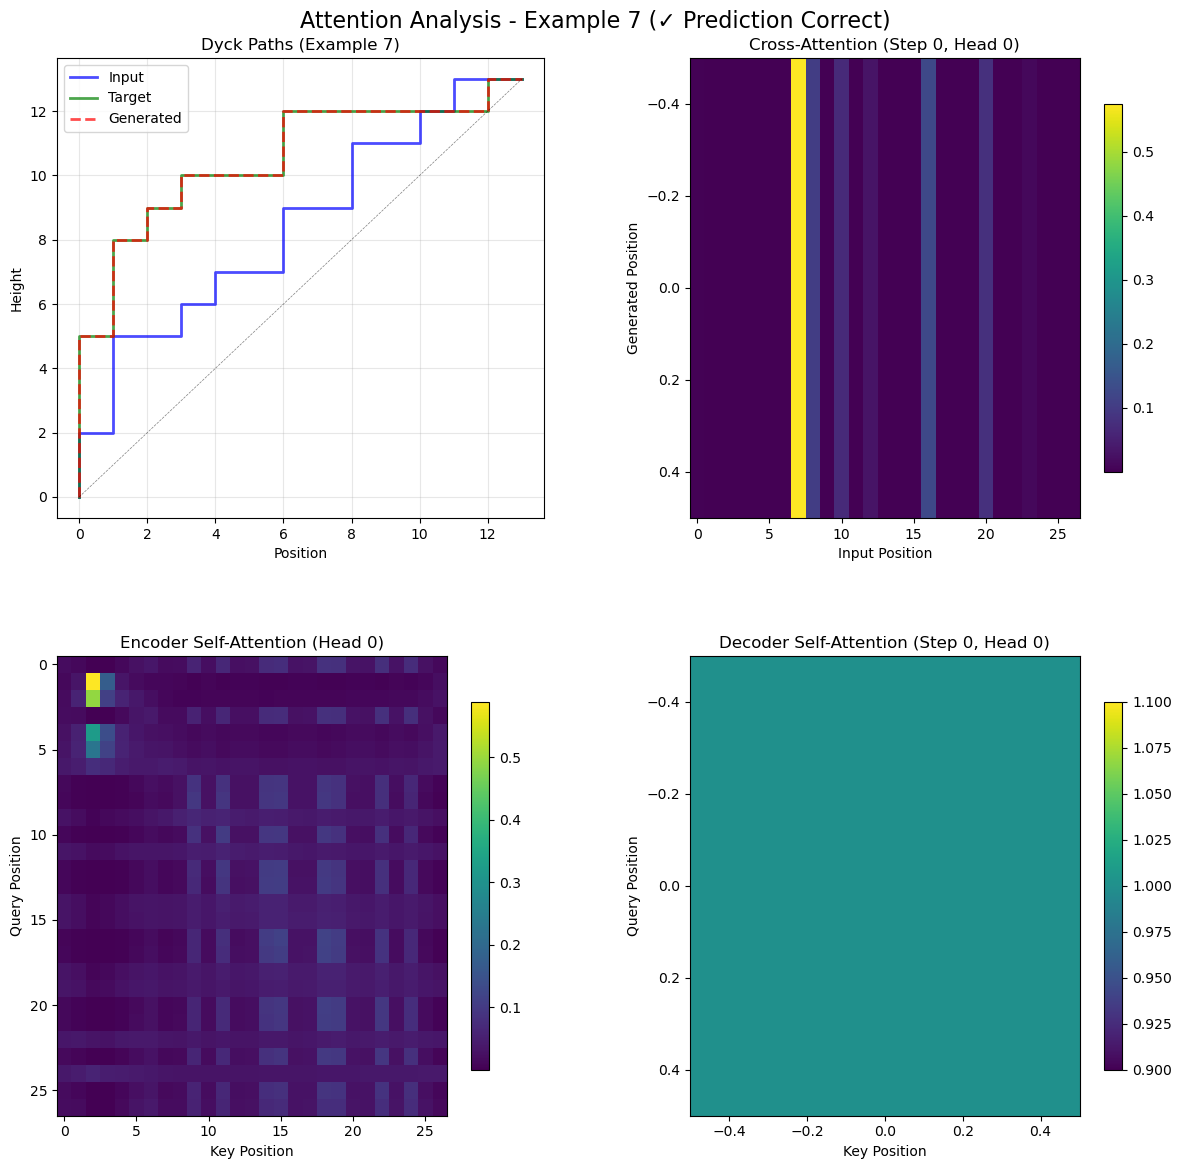

In [41]:
# Example: Analyze data example #15
# this if for all attention heads numbered 0 at step 21 (the 22th token generated in the sequence)
#=================
ex_idx = 7  # the index of the first example to analyze
encoder_att_head = 0  # which encoder self-attention head to analyze
decoder_att_head = 0  # which decoder self-attention head to analyze
cross_att_head = 0  # which cross-attention head to analyze
step = 0 # which token is being generated in the sequence when analyzing cross-attention
# some plotting parameters
figsize = (12,12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
# outputs = analyze_cross_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples)
print(f"Input: {decode(examples['inputs'][ex_idx], dataset.dictionary)}")
print(f"Target: {decode(examples['targets'][ex_idx], dataset.dictionary)}")
messed_input = examples['inputs'][ex_idx].clone()
# messed_input[-2:] = 1        
messed_input[1:7] = 1
# messed_input[11:16] = 1
print(f"predit: {decode(model.generate(src=messed_input, tgt = torch.tensor([0]).unsqueeze(0), max_new_tokens=max_new_tokens).squeeze(), dataset.dictionary)}")
outputs = attention_example(model, examples, ex_idx=ex_idx, step=step, encoder_att_head=encoder_att_head, decoder_att_head=decoder_att_head, cross_att_head=cross_att_head, figsize=figsize, cmap=cmap)

In [43]:
examples['inputs'][:10, :]

tensor([[0, 3, 3, 3, 2, 2, 3, 2, 2, 3, 2, 3, 3, 2, 3, 3, 2, 2, 3, 3, 3, 2, 2, 3,
         2, 2, 2],
        [0, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 3, 3, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 3,
         2, 3, 2],
        [0, 3, 2, 3, 2, 3, 2, 3, 2, 3, 3, 3, 2, 3, 2, 2, 3, 2, 3, 3, 2, 3, 3, 2,
         2, 2, 2],
        [0, 3, 2, 3, 2, 3, 3, 3, 2, 2, 3, 2, 2, 3, 3, 2, 3, 2, 3, 2, 3, 3, 2, 2,
         3, 2, 2],
        [0, 3, 3, 2, 3, 2, 2, 3, 3, 3, 2, 3, 2, 2, 2, 3, 2, 3, 3, 3, 2, 3, 3, 2,
         2, 2, 2],
        [0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 2, 2, 3,
         3, 2, 2],
        [0, 3, 3, 3, 2, 2, 2, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 3,
         2, 3, 2],
        [0, 3, 3, 2, 3, 3, 3, 2, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3, 2, 2, 3, 2,
         3, 2, 2],
        [0, 3, 3, 3, 3, 2, 3, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 3, 2, 2, 3, 3, 2, 2,
         3, 2, 2],
        [0, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3, 3, 2,
         2, 3, 2]])

In [44]:
torch.full((examples['inputs'].shape[0], 1), 0)

tensor([[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]])

In [48]:
# only compare the accuracy of the generated outputs with targets for the first n steps
n_steps = 2
acc = 0

# Fix: Make sure src and tgt have the same batch size
batch_size = 10  # We're only using the first example
generated = model.generate(
    src=examples['inputs'][:batch_size, :], 
    tgt=torch.full((batch_size, 1), 0).to(examples['inputs'].device), 
    max_new_tokens=n_steps
)

print(f"Generated shape: {generated.shape}")
print(f"Input shape: {examples['inputs'][:batch_size, :].shape}")
print(f"Target shape: {examples['targets'][:batch_size, :].shape}")

# Compare with the actual target
actual_target = examples['targets'][:batch_size, :]
print(f"Generated: {decode(generated[0], dataset.dictionary)}")
print(f"Target: {decode(actual_target[0], dataset.dictionary)}")

# Calculate accuracy for the generated portion (excluding the initial BOS token)
generated_tokens = generated[:, :n_steps]  # Skip BOS, take n_steps tokens
target_tokens = actual_target[:, :n_steps]    # First n_steps of target
accuracy = (generated_tokens == target_tokens).float().mean()
print(f"Accuracy for first {n_steps} tokens: {accuracy:.4f}")

Generated shape: torch.Size([10, 3])
Input shape: torch.Size([10, 27])
Target shape: torch.Size([10, 27])
Generated: bos 1 1
Target: bos 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 0 0
Accuracy for first 2 tokens: 1.0000


In [ ]:
n_steps = 2
messed_amount = 10
# now mess up all inputs's 1 to 5 tokens to be 1
messed_input = examples['inputs'].clone()
messed_input[:, :messed_amount] = 1

# Fix: Make sure src and tgt have the same batch size
batch_size = 10000  # We're only using the first example
generated = model.generate(
    src=messed_input[:batch_size, :], 
    tgt=torch.full((batch_size, 1), 0).to(examples['inputs'].device), 
    max_new_tokens=n_steps
)

# # Compare with the actual target
# actual_target = examples['targets'][:batch_size, :]
# print(f"Generated: {decode(generated[0], dataset.dictionary)}")
# print(f"Target: {decode(actual_target[0], dataset.dictionary)}")

# Calculate accuracy for the generated portion (excluding the initial BOS token)
generated_tokens = generated[:, :n_steps]  # Skip BOS, take n_steps tokens
target_tokens = actual_target[:, :n_steps]    # First n_steps of target
accuracy = (generated_tokens == target_tokens).all(dim=1).float().mean()
print(f"Accuracy for first {n_steps} tokens: {accuracy:.4f}")

Accuracy for first 2 tokens: 1.0000


In [82]:
n_steps = 5
acc_res=[]
for messed_amount in range(1, 28):
    print(f"messed_amount: {messed_amount}")
    # now mess up all inputs's 1 to 5 tokens to be 1
    messed_input = examples['inputs'].clone()
    messed_input[:, :messed_amount] = 1

    # Fix: Make sure src and tgt have the same batch size
    batch_size = 10000  # We're only using the first example
    generated = model.generate(
        src=messed_input[:batch_size, :], 
        tgt=torch.full((batch_size, 1), 0).to(examples['inputs'].device), 
        max_new_tokens=n_steps
    )

    # # Compare with the actual target
    # actual_target = examples['targets'][:batch_size, :]
    # print(f"Generated: {decode(generated[0], dataset.dictionary)}")
    # print(f"Target: {decode(actual_target[0], dataset.dictionary)}")

    # Calculate accuracy for the generated portion (excluding the initial BOS token)
    generated_tokens = generated[:, :n_steps]  # Skip BOS, take n_steps tokens
    target_tokens = actual_target[:, :n_steps]    # First n_steps of target
    accuracy = (generated_tokens == target_tokens).all(dim=1).float().mean()
    acc_res.append(accuracy.item())
    print(f"Accuracy for first {n_steps} tokens: {accuracy:.4f}")

messed_amount: 1
Accuracy for first 5 tokens: 0.9579
messed_amount: 2
Accuracy for first 5 tokens: 0.9579
messed_amount: 2
Accuracy for first 5 tokens: 0.9569
messed_amount: 3
Accuracy for first 5 tokens: 0.9569
messed_amount: 3
Accuracy for first 5 tokens: 0.9579
messed_amount: 4
Accuracy for first 5 tokens: 0.9579
messed_amount: 4
Accuracy for first 5 tokens: 0.9581
messed_amount: 5
Accuracy for first 5 tokens: 0.9581
messed_amount: 5
Accuracy for first 5 tokens: 0.9577
messed_amount: 6
Accuracy for first 5 tokens: 0.9577
messed_amount: 6
Accuracy for first 5 tokens: 0.9566
messed_amount: 7
Accuracy for first 5 tokens: 0.9566
messed_amount: 7
Accuracy for first 5 tokens: 0.9048
messed_amount: 8
Accuracy for first 5 tokens: 0.9048
messed_amount: 8
Accuracy for first 5 tokens: 0.8175
messed_amount: 9
Accuracy for first 5 tokens: 0.8175
messed_amount: 9
Accuracy for first 5 tokens: 0.7496
messed_amount: 10
Accuracy for first 5 tokens: 0.7496
messed_amount: 10
Accuracy for first 5 tokens

Text(0.5, 1.0, 'First 4 Dyck path steps accuracy')

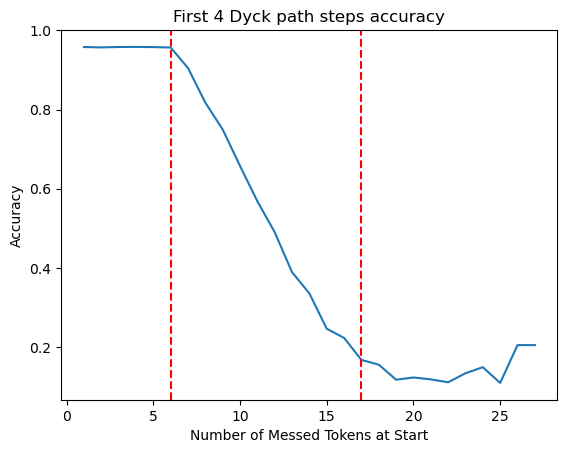

In [83]:
plt.plot(range(1, 28), acc_res)
plt.xlabel('Number of Messed Tokens at Start')
plt.ylabel('Accuracy')
# plot a verticle line at x = 7
plt.axvline(x=6, color='r', linestyle='--')
plt.axvline(x=17, color='r', linestyle='--')
plt.title(f"First {n_steps - 1} Dyck path steps accuracy")

Text(0.5, 1.0, 'First 3 Dyck path steps accuracy')

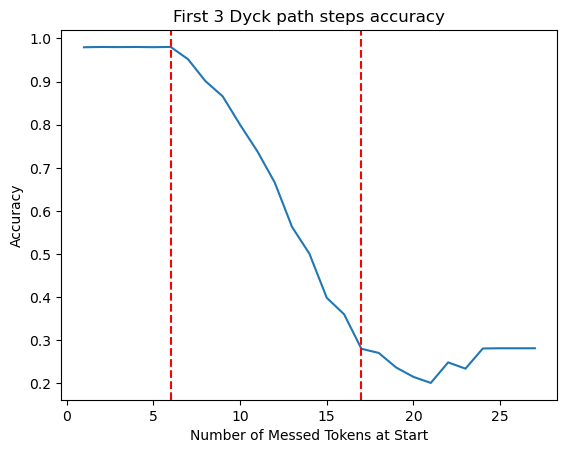

In [81]:
plt.plot(range(1, 28), acc_res)
plt.xlabel('Number of Messed Tokens at Start')
plt.ylabel('Accuracy')
# plot a verticle line at x = 7
plt.axvline(x=6, color='r', linestyle='--')
plt.axvline(x=17, color='r', linestyle='--')
plt.title(f"First {n_steps - 1} Dyck path steps accuracy")

Text(0.5, 1.0, 'First 2 Dyck path steps accuracy')

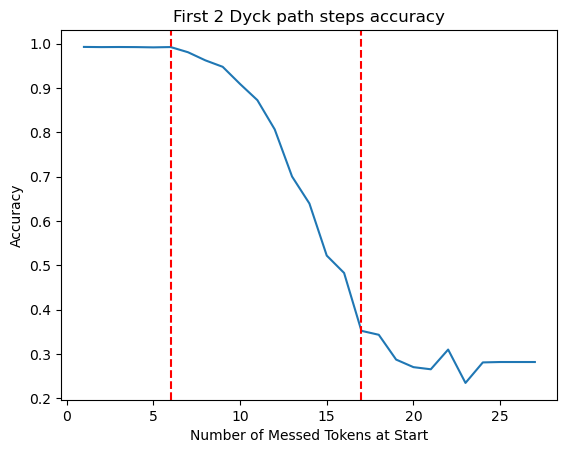

In [79]:
plt.plot(range(1, 28), acc_res)
plt.xlabel('Number of Messed Tokens at Start')
plt.ylabel('Accuracy')
# plot a verticle line at x = 7
plt.axvline(x=6, color='r', linestyle='--')
plt.axvline(x=17, color='r', linestyle='--')
plt.title("First 2 Dyck path steps accuracy")

Target tokens shape: torch.Size([10000, 5])

Value counts for target_tokens[:, 4]:
  Token 2 (0): 3510 occurrences (35.10%)
  Token 3 (1): 6490 occurrences (64.90%)


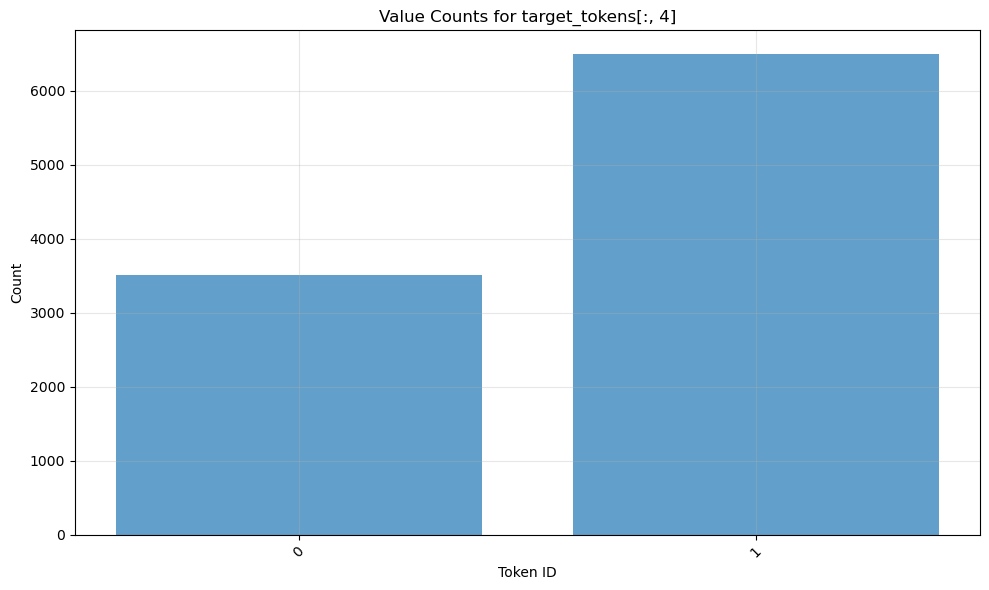

In [107]:
# value count target_tokens[:,4]
import pandas as pd

# Get the target tokens (first 10000 examples, first 5 steps)
target_tokens = examples['targets'][:10000, :5]
print(f"Target tokens shape: {target_tokens.shape}")

# Value count for the 4th column (index 4)
if target_tokens.shape[1] > 4:  # Check if we have at least 5 columns
    values, counts = torch.unique(target_tokens[:, 4], return_counts=True)
    
    print(f"\nValue counts for target_tokens[:, 4]:")
    for val, count in zip(values.cpu().numpy(), counts.cpu().numpy()):
        token_name = dataset.dictionary.get(val.item(), f"UNK({val.item()})")
        print(f"  Token {val.item()} ({token_name}): {count} occurrences ({count/len(target_tokens)*100:.2f}%)")
    
    # Also create a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(values.cpu().numpy(), counts.cpu().numpy(), alpha=0.7)
    plt.xlabel('Token ID')
    plt.ylabel('Count')
    plt.title('Value Counts for target_tokens[:, 4]')
    
    # Add token names as x-tick labels if not too many unique values
    if len(values) <= 10:
        token_names = [dataset.dictionary.get(val.item(), f"UNK({val.item()})") for val in values]
        plt.xticks(values.cpu().numpy(), token_names, rotation=45)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"target_tokens only has {target_tokens.shape[1]} columns, cannot access column 4")

### Example 2b. Visualize Cross Attentions for a Batch of Examples

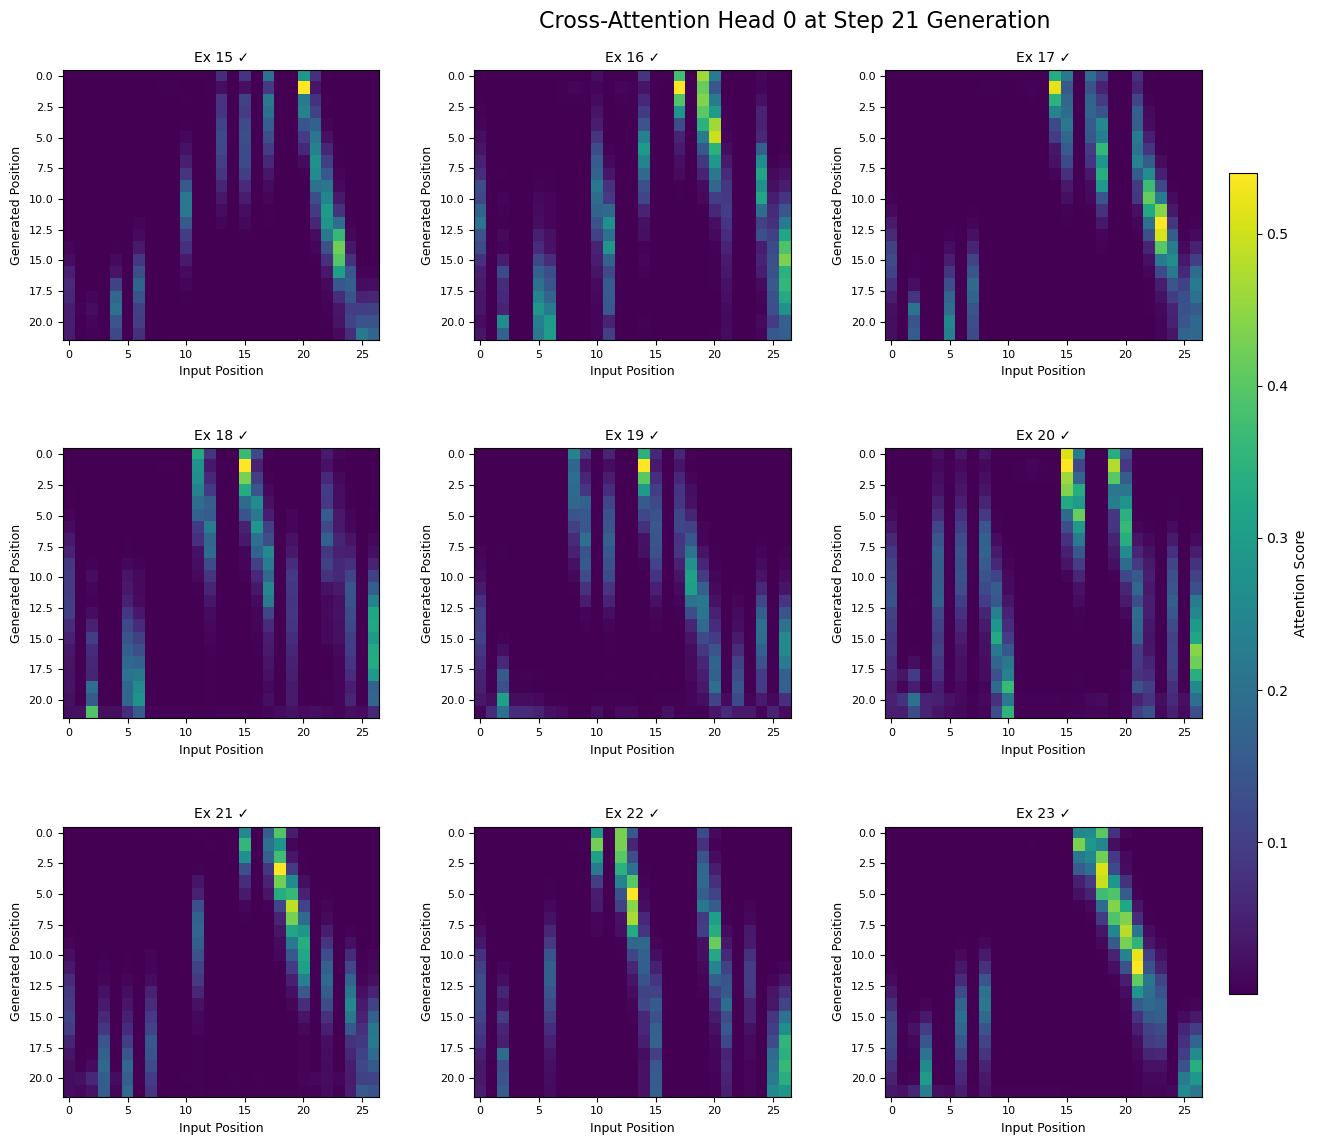

In [12]:
# Example: Analyze 9 examples starting from example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
# The ✓ and ✗ in the title indicate whether the Dyck path is predicted correctly or not
#=================
start_idx = 15  # the index of the first example to analyze
num_examples = 9  # Number of examples to show
att_head = 0    # attention head to visualize
step = 21  # which token is being generated in the sequence when analyzing cross-attention
# some plotting parameters
figsize = (16, 12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_cross_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples, figsize=figsize, cmap=cmap)

### Example 2c. Visualize encoder self attention for a batch of examples

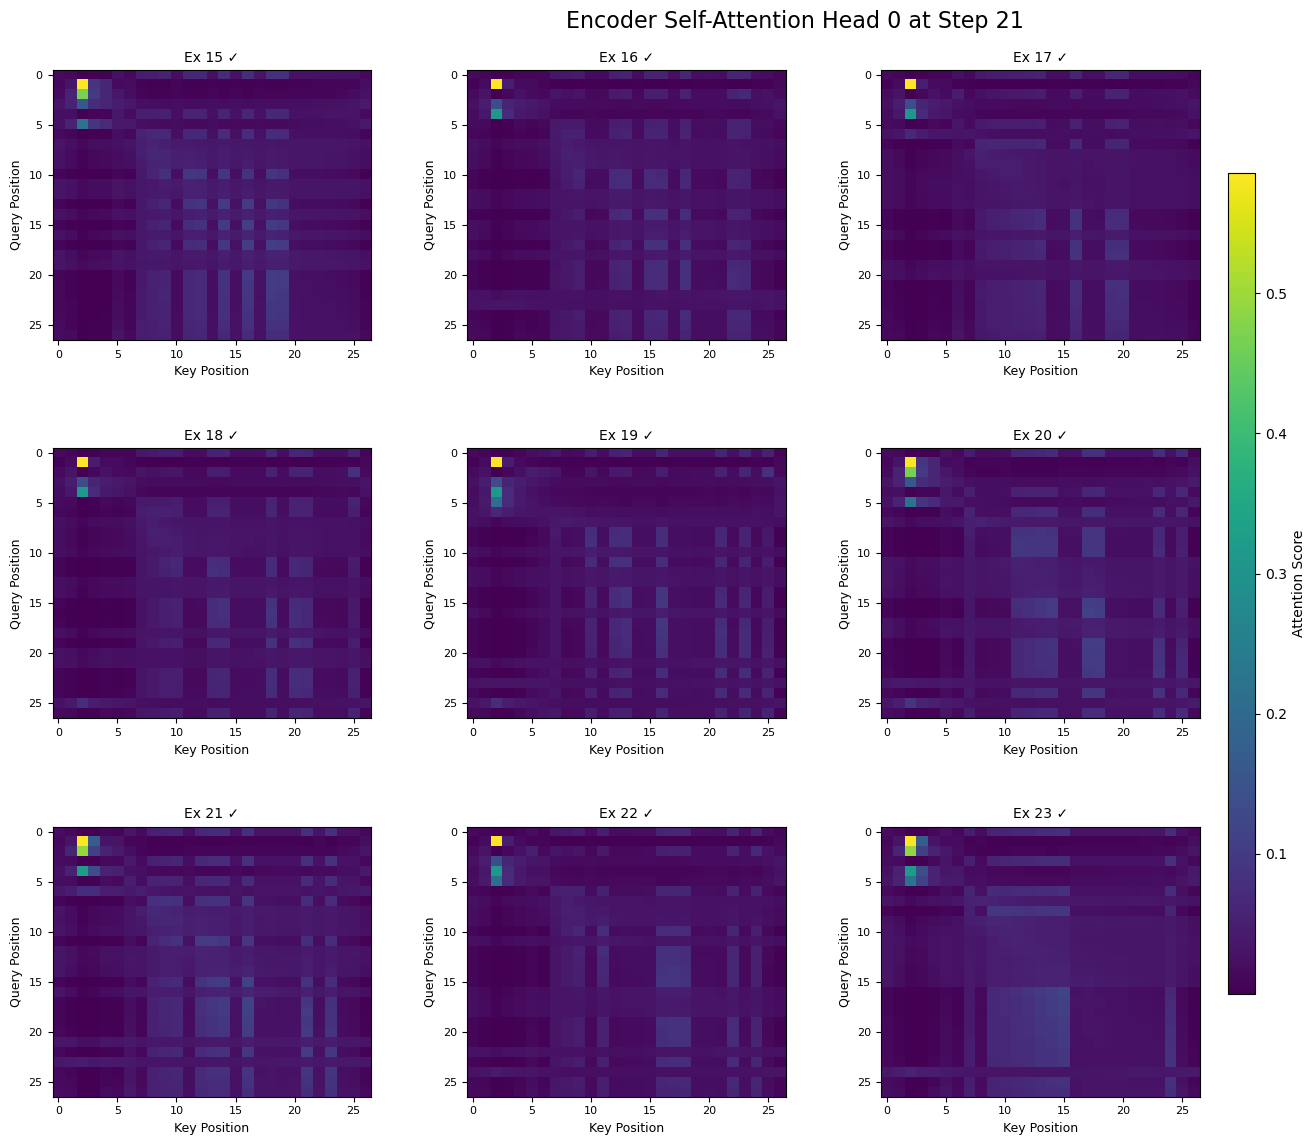

In [40]:
# Example: Analyze 9 examples starting from example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
# The ✓ and ✗ in the title indicate whether the Dyck path is predicted correctly or not
#=================
start_idx = 15  # the index of the first example to analyze
num_examples = 9  # Number of examples to show
att_head = 0    # attention head to visualize
step = 21  # which token is being generated in the sequence when analyzing attention
# some plotting parameters
figsize = (16, 12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_encoder_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples, figsize=figsize, cmap=cmap)

### Example 2d. Visualize decoder self attention for a batch of examples

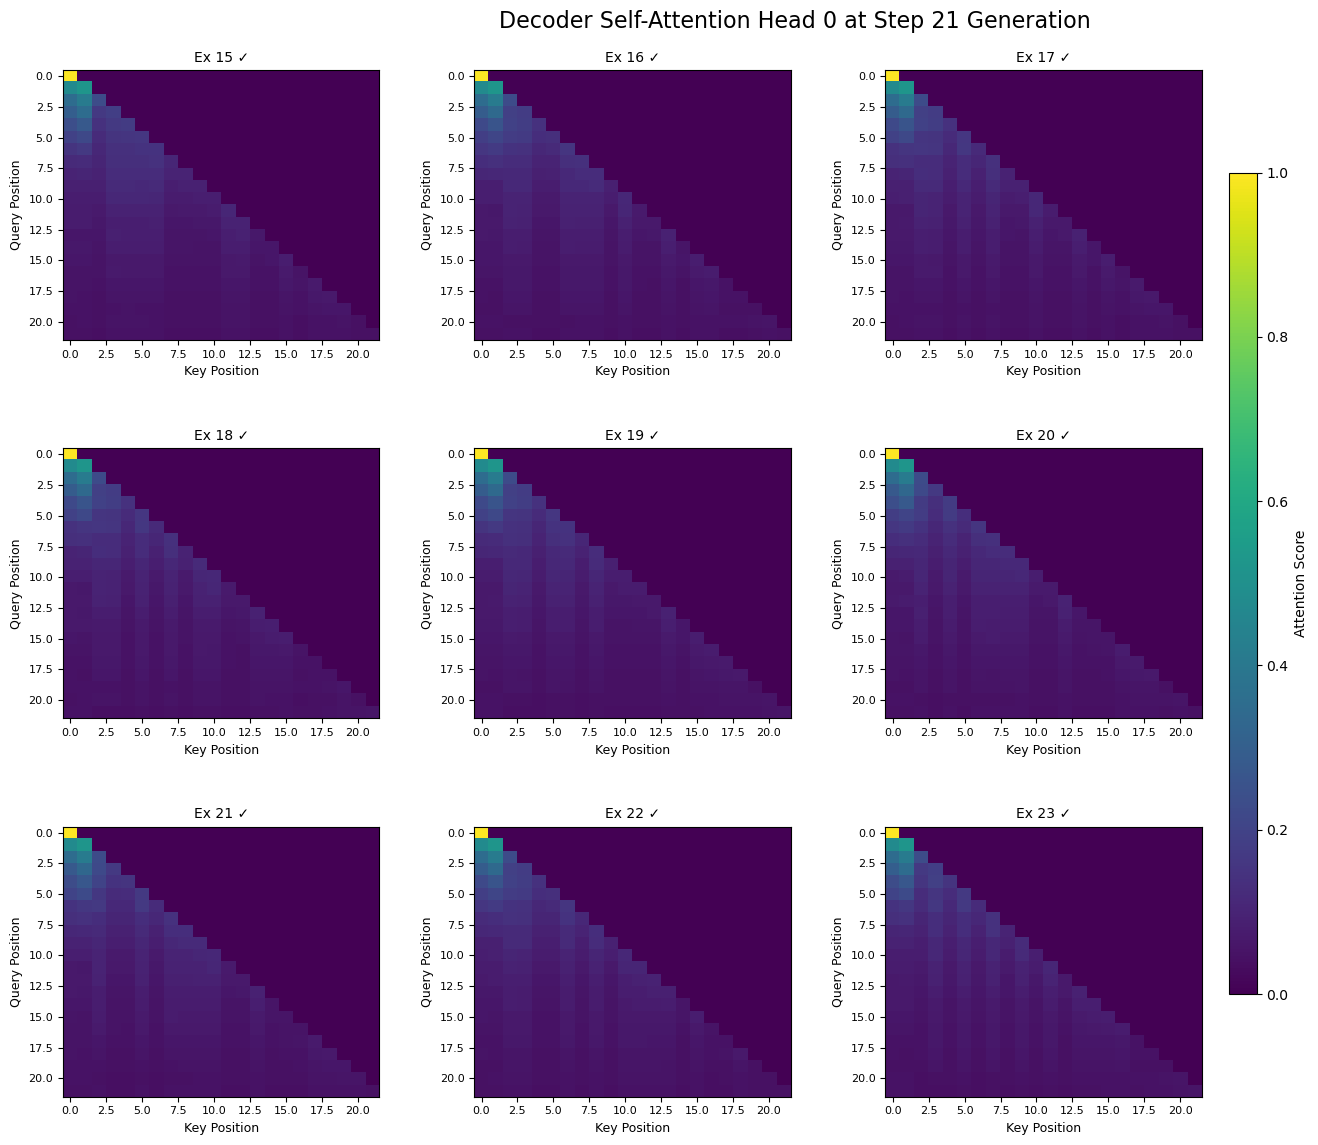

In [13]:
# Example: Analyze 9 examples starting from example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
# The ✓ and ✗ in the title indicate whether the Dyck path is predicted correctly or not
#=================
start_idx = 15  # the index of the first example to analyze
num_examples = 9  # Number of examples to show
att_head = 0    # attention head to visualize
step = 21  # which token is being generated in the sequence when analyzing attention
# some plotting parameters
figsize = (16, 12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_decoder_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples, figsize=figsize, cmap=cmap)

### Example 2e. Visualize cross attention across all the steps

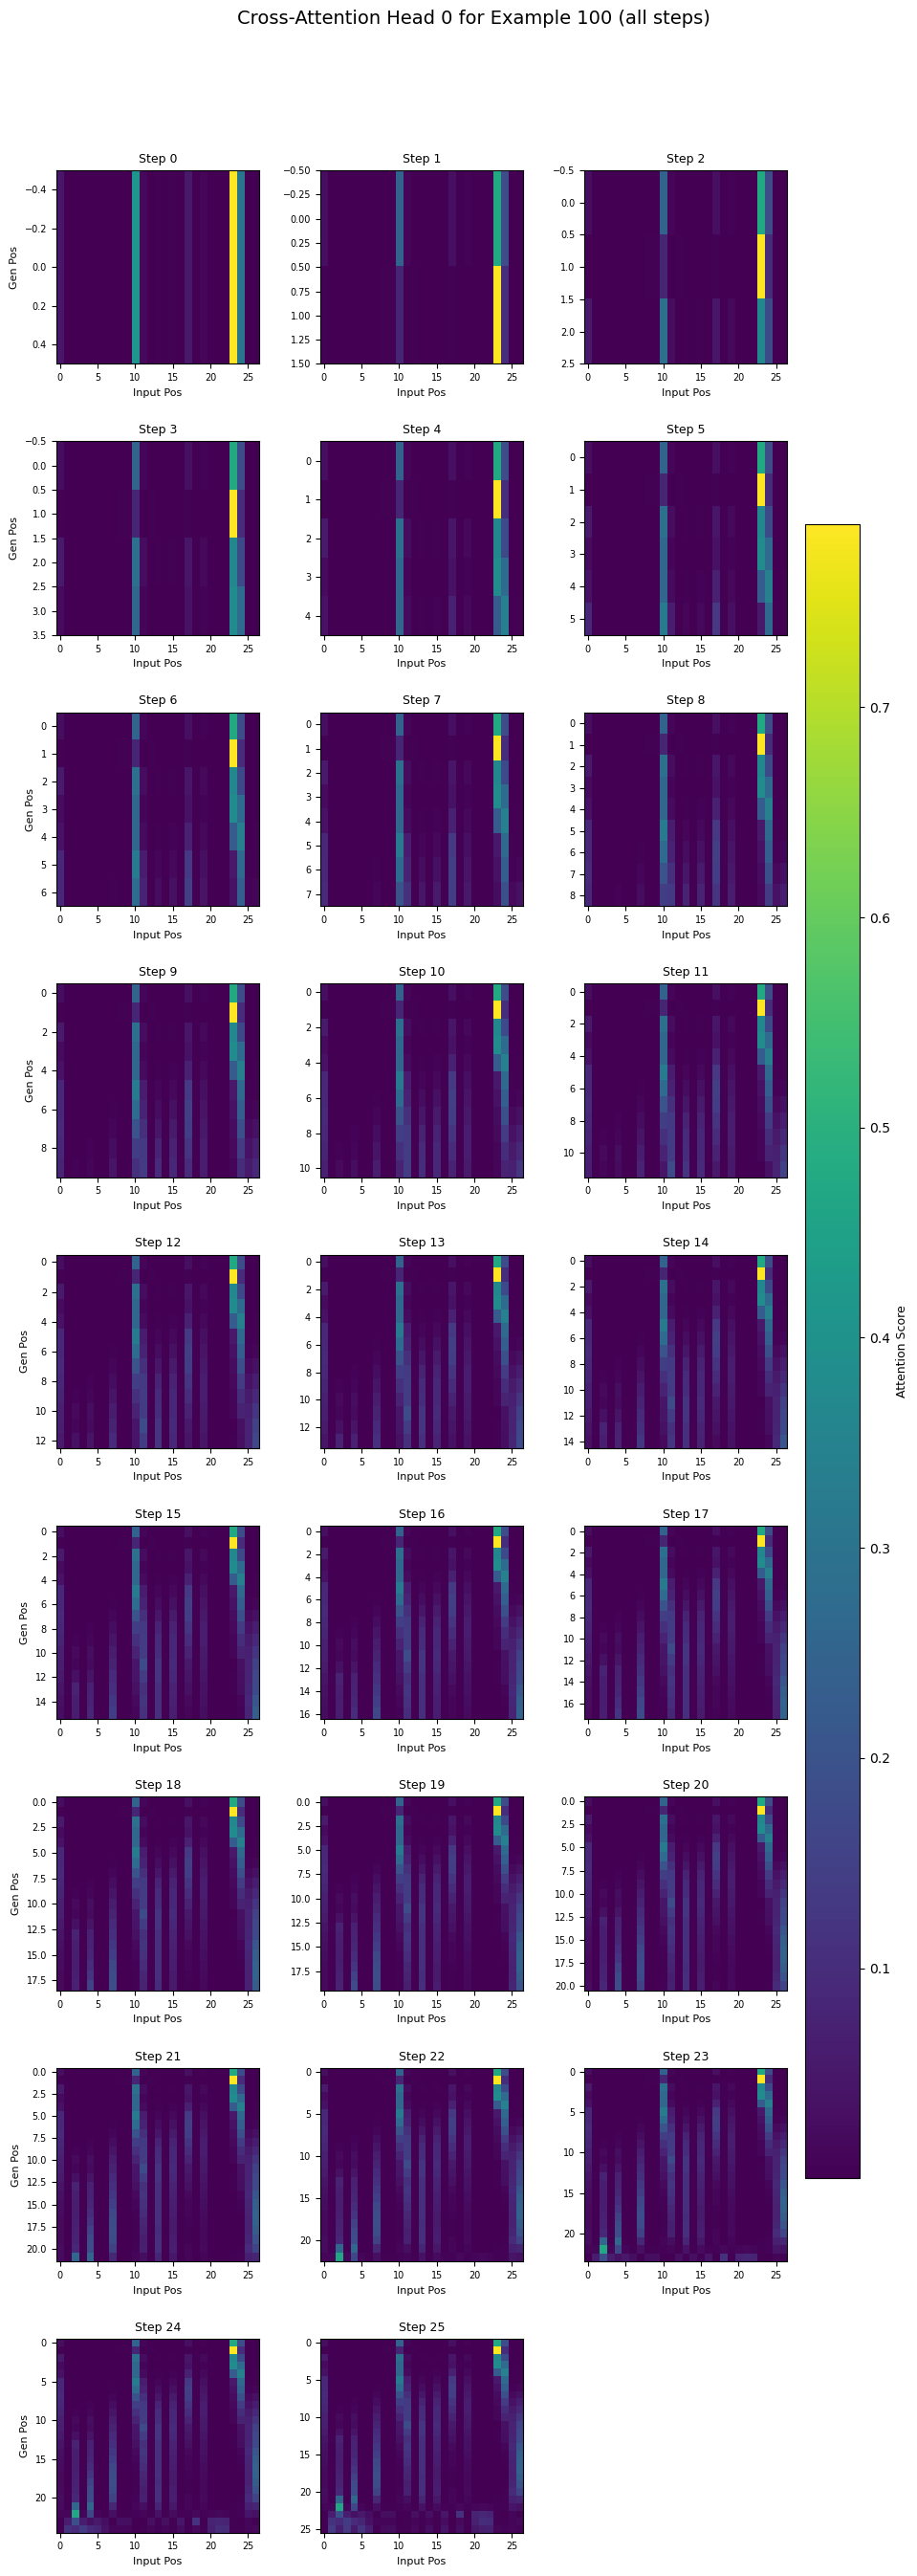

In [12]:
# Example: Analyze example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
#=================
ex_idx = 100  # the index of the first example to analyze
att_head = 0    # attention head to visualize
# some plotting parameters
figsize = (10,28)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_cross_attention_all_steps(model, examples, ex_idx=ex_idx, att_head=att_head, figsize=figsize, cmap=cmap)

### Example 2f. PCA of encoder and decoder embeddings

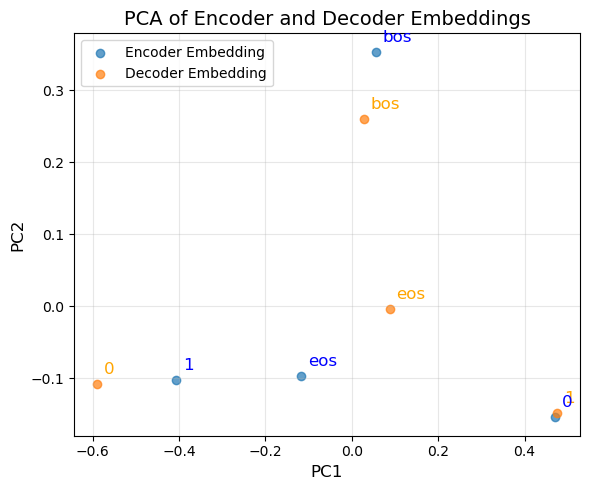

In [15]:
# run a PCA on the encoder and decoder embeddings
outputs = analyze_embeddings_pca(model, dataset, figsize=(6, 5), alpha=0.7, fontsize=12)

### Example 2g: PCA of positional embeddings

Positional encoding shape: (27, 128)


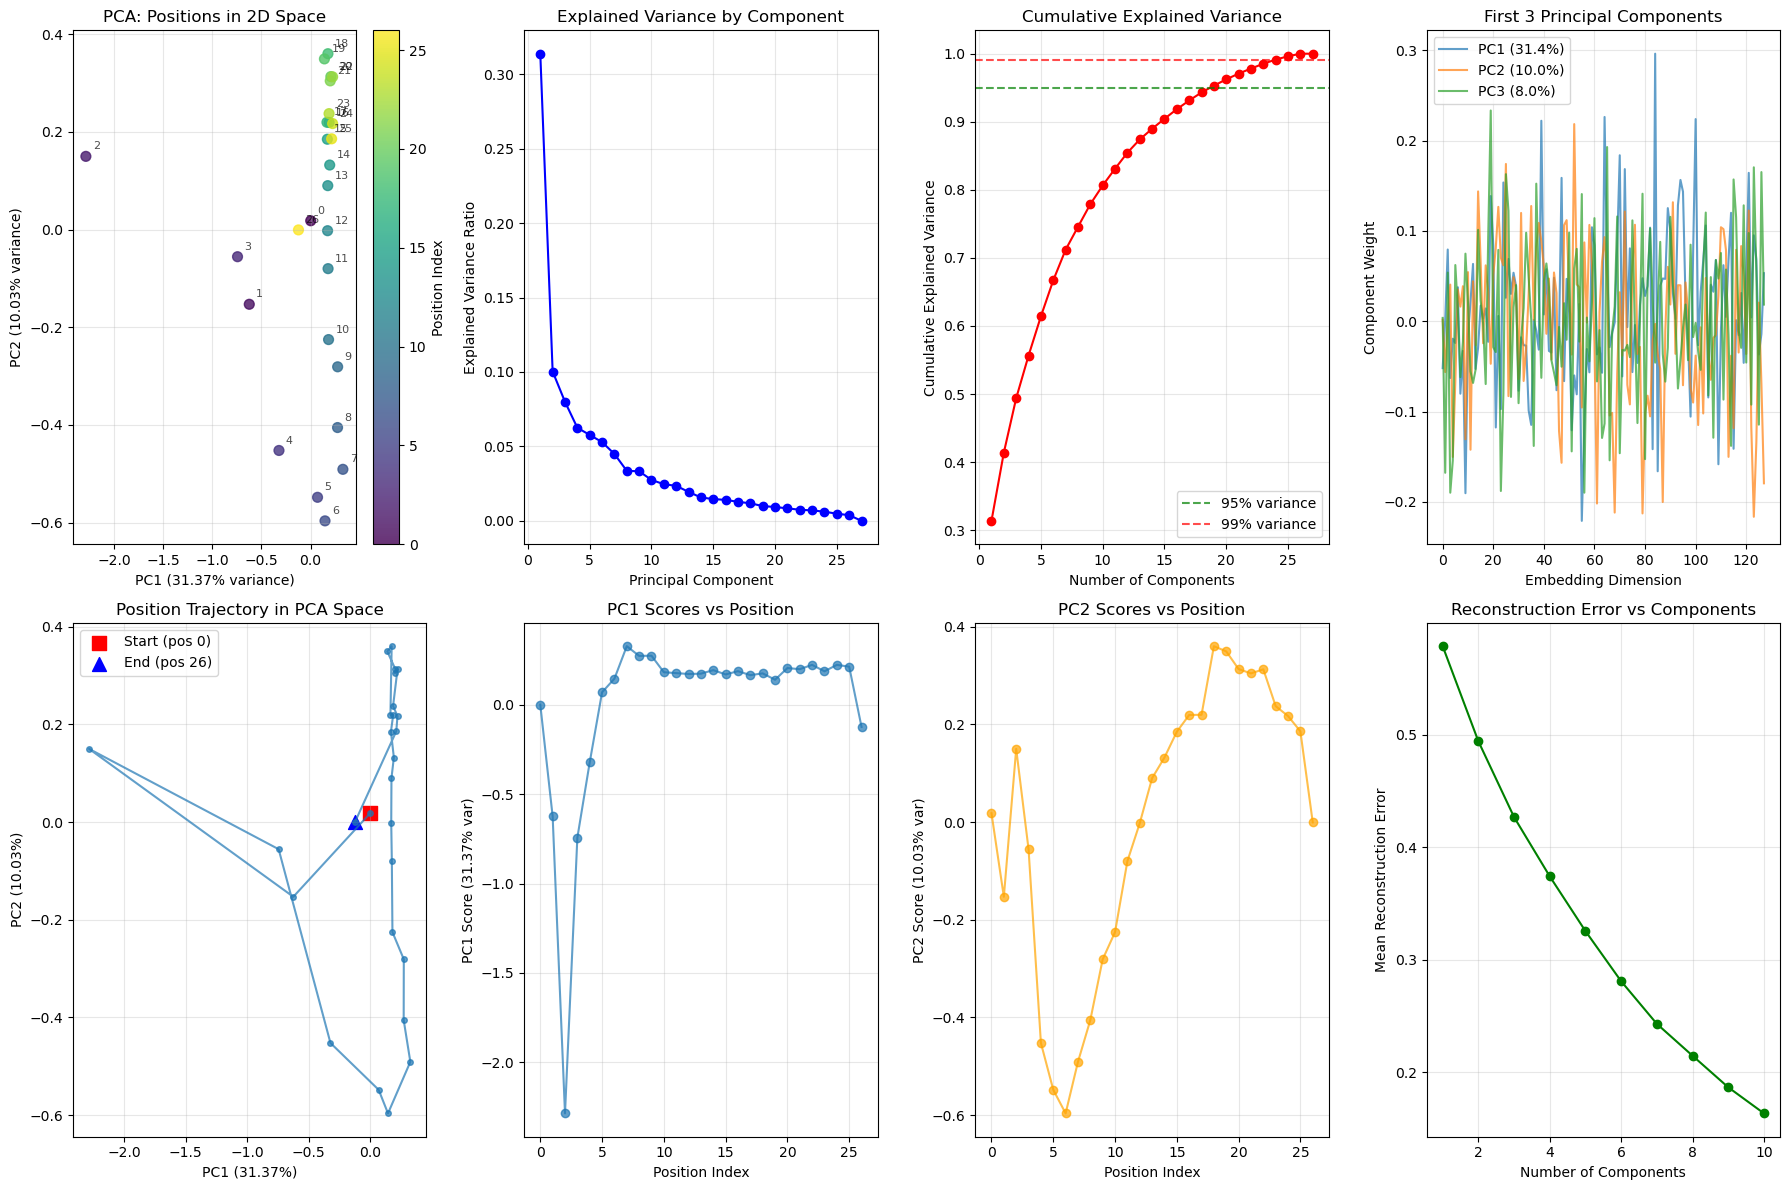


PCA Analysis Summary:
  Original shape: (27, 128)
  Total variance explained by first 2 components: 41.40%
  PC1 explains 31.37% of variance
  PC2 explains 10.03% of variance
  Components needed for 95% variance: 19
  Components needed for 99% variance: 24

First 5 positions in PC space:
  Position 0: PC1=0.001, PC2=0.018
  Position 1: PC1=-0.624, PC2=-0.153
  Position 2: PC1=-2.286, PC2=0.150
  Position 3: PC1=-0.743, PC2=-0.056
  Position 4: PC1=-0.322, PC2=-0.452

PC space characteristics:
  PC1 range: 2.615
  PC2 range: 0.956
  Aspect ratio (PC1/PC2): 2.735


In [16]:
# PCA of model.src_pos_encoding
from sklearn.decomposition import PCA

# Extract positional encoding weights
pos_encoding_weights = model.src_pos_encoding.pe.weight.data.cpu().numpy()
print(f"Positional encoding shape: {pos_encoding_weights.shape}")

# Perform PCA with multiple components
n_components = min(28, pos_encoding_weights.shape[0], pos_encoding_weights.shape[1])
pca = PCA(n_components=n_components)
pos_pca_full = pca.fit_transform(pos_encoding_weights)

# Also do 2D PCA for visualization
pca_2d = PCA(n_components=2)
pos_pca_2d = pca_2d.fit_transform(pos_encoding_weights)

# Create comprehensive PCA visualization
plt.figure(figsize=(18, 12))

# Plot 1: 2D PCA scatter plot
plt.subplot(2, 4, 1)
scatter = plt.scatter(pos_pca_2d[:, 0], pos_pca_2d[:, 1], c=range(len(pos_pca_2d)), cmap='viridis', alpha=0.8, s=50)
plt.colorbar(scatter, label='Position Index')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: Positions in 2D Space')
plt.grid(True, alpha=0.3)

# Add position labels for small datasets
if len(pos_pca_2d) <= 30:
    for i, (x, y) in enumerate(pos_pca_2d):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

# Plot 2: Explained variance ratio
plt.subplot(2, 4, 2)
plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.grid(True, alpha=0.3)

# Plot 3: Cumulative explained variance
plt.subplot(2, 4, 3)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_components + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% variance')
plt.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: First few principal components
plt.subplot(2, 4, 4)
for i in range(min(3, n_components)):
    plt.plot(pca.components_[i], label=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})', alpha=0.7)
plt.xlabel('Embedding Dimension')
plt.ylabel('Component Weight')
plt.title('First 3 Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Position trajectory in PC1-PC2 space
plt.subplot(2, 4, 5)
plt.plot(pos_pca_2d[:, 0], pos_pca_2d[:, 1], 'o-', alpha=0.7, markersize=4)
plt.scatter(pos_pca_2d[0, 0], pos_pca_2d[0, 1], c='red', s=100, marker='s', label='Start (pos 0)')
plt.scatter(pos_pca_2d[-1, 0], pos_pca_2d[-1, 1], c='blue', s=100, marker='^', label=f'End (pos {len(pos_pca_2d)-1})')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.title('Position Trajectory in PCA Space')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: PC1 vs position index
plt.subplot(2, 4, 6)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 0], 'o-', alpha=0.7)
plt.xlabel('Position Index')
plt.ylabel(f'PC1 Score ({pca_2d.explained_variance_ratio_[0]:.2%} var)')
plt.title('PC1 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 7: PC2 vs position index
plt.subplot(2, 4, 7)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 1], 'o-', alpha=0.7, color='orange')
plt.xlabel('Position Index')
plt.ylabel(f'PC2 Score ({pca_2d.explained_variance_ratio_[1]:.2%} var)')
plt.title('PC2 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 8: Reconstruction error
plt.subplot(2, 4, 8)
reconstruction_errors = []
for n in range(1, min(n_components, 10) + 1):
    pca_temp = PCA(n_components=n)
    transformed = pca_temp.fit_transform(pos_encoding_weights)
    reconstructed = pca_temp.inverse_transform(transformed)
    error = np.mean(np.sum((pos_encoding_weights - reconstructed) ** 2, axis=1))
    reconstruction_errors.append(error)

plt.plot(range(1, len(reconstruction_errors) + 1), reconstruction_errors, 'go-')
plt.xlabel('Number of Components')
plt.ylabel('Mean Reconstruction Error')
plt.title('Reconstruction Error vs Components')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nPCA Analysis Summary:")
print(f"  Original shape: {pos_encoding_weights.shape}")
print(f"  Total variance explained by first 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"  PC1 explains {pca_2d.explained_variance_ratio_[0]:.2%} of variance")
print(f"  PC2 explains {pca_2d.explained_variance_ratio_[1]:.2%} of variance")
print(f"  Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"  Components needed for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")

# Print the first few PC scores
print(f"\nFirst 5 positions in PC space:")
for i in range(min(5, len(pos_pca_2d))):
    print(f"  Position {i}: PC1={pos_pca_2d[i, 0]:.3f}, PC2={pos_pca_2d[i, 1]:.3f}")

# Analyze patterns in PC space
pc1_range = pos_pca_2d[:, 0].max() - pos_pca_2d[:, 0].min()
pc2_range = pos_pca_2d[:, 1].max() - pos_pca_2d[:, 1].min()
print(f"\nPC space characteristics:")
print(f"  PC1 range: {pc1_range:.3f}")
print(f"  PC2 range: {pc2_range:.3f}")
print(f"  Aspect ratio (PC1/PC2): {pc1_range/pc2_range:.3f}")

Positional encoding shape: (27, 128)


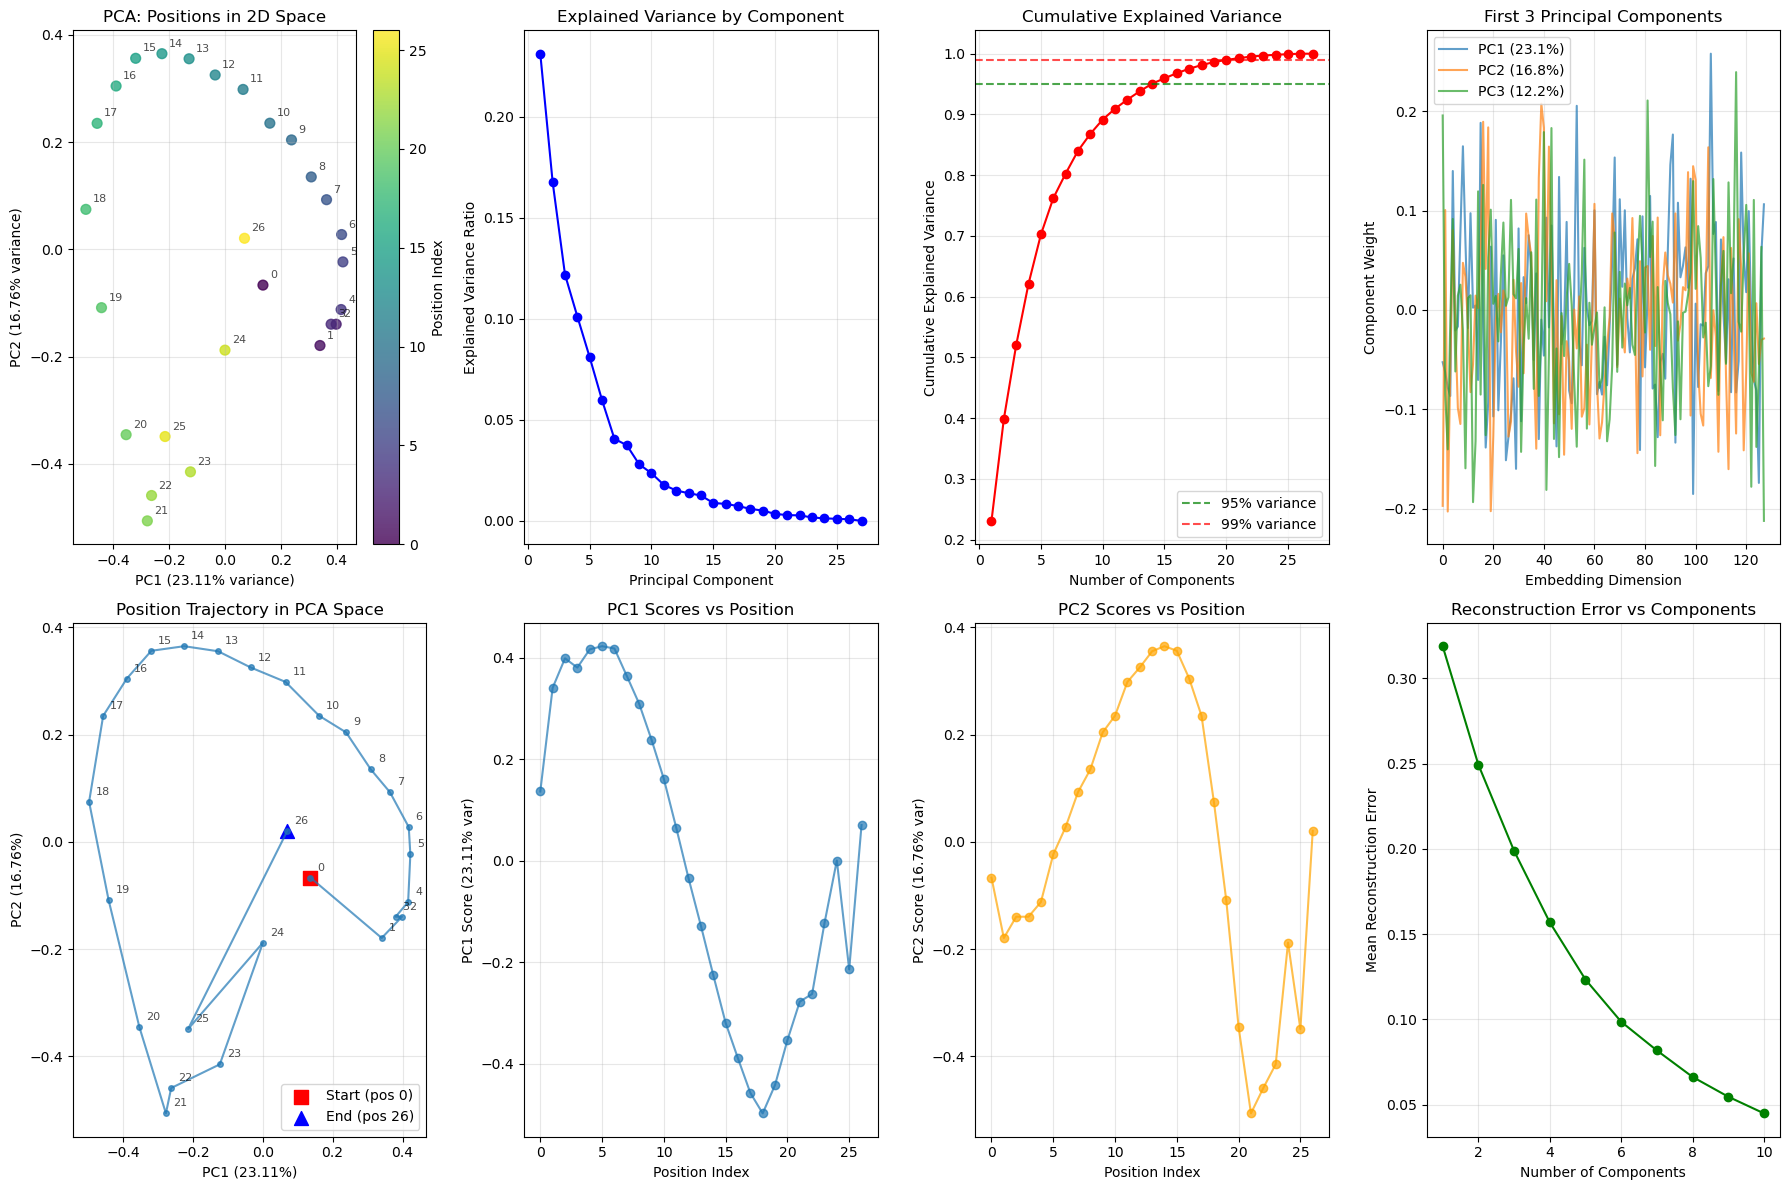


PCA Analysis Summary:
  Original shape: (27, 128)
  Total variance explained by first 2 components: 39.86%
  PC1 explains 23.11% of variance
  PC2 explains 16.76% of variance
  Components needed for 95% variance: 14
  Components needed for 99% variance: 21

First 5 positions in PC space:
  Position 0: PC1=0.136, PC2=-0.067
  Position 1: PC1=0.340, PC2=-0.179
  Position 2: PC1=0.398, PC2=-0.140
  Position 3: PC1=0.380, PC2=-0.139
  Position 4: PC1=0.416, PC2=-0.112

PC space characteristics:
  PC1 range: 0.920
  PC2 range: 0.871
  Aspect ratio (PC1/PC2): 1.055


In [17]:
# PCA of model.tgt_pos_encoding
from sklearn.decomposition import PCA

# Extract positional encoding weights
pos_encoding_weights = model.tgt_pos_encoding.pe.weight.data.cpu().numpy()
print(f"Positional encoding shape: {pos_encoding_weights.shape}")

# Perform PCA with multiple components
n_components = min(56, pos_encoding_weights.shape[0], pos_encoding_weights.shape[1])
pca = PCA(n_components=n_components)
pos_pca_full = pca.fit_transform(pos_encoding_weights)

# Also do 2D PCA for visualization
pca_2d = PCA(n_components=2)
pos_pca_2d = pca_2d.fit_transform(pos_encoding_weights)

# Create comprehensive PCA visualization
plt.figure(figsize=(18, 12))

# Plot 1: 2D PCA scatter plot
plt.subplot(2, 4, 1)
scatter = plt.scatter(pos_pca_2d[:, 0], pos_pca_2d[:, 1], c=range(len(pos_pca_2d)), cmap='viridis', alpha=0.8, s=50)
plt.colorbar(scatter, label='Position Index')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: Positions in 2D Space')
plt.grid(True, alpha=0.3)

# Add position labels for small datasets
# if len(pos_pca_2d) <= 30:
#     for i, (x, y) in enumerate(pos_pca_2d):
#         plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
for i, (x, y) in enumerate(pos_pca_2d):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)


# Plot 2: Explained variance ratio
plt.subplot(2, 4, 2)
plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.grid(True, alpha=0.3)

# Plot 3: Cumulative explained variance
plt.subplot(2, 4, 3)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_components + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% variance')
plt.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: First few principal components
plt.subplot(2, 4, 4)
for i in range(min(3, n_components)):
    plt.plot(pca.components_[i], label=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})', alpha=0.7)
plt.xlabel('Embedding Dimension')
plt.ylabel('Component Weight')
plt.title('First 3 Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Position trajectory in PC1-PC2 space
plt.subplot(2, 4, 5)
plt.plot(pos_pca_2d[:, 0], pos_pca_2d[:, 1], 'o-', alpha=0.7, markersize=4)
plt.scatter(pos_pca_2d[0, 0], pos_pca_2d[0, 1], c='red', s=100, marker='s', label='Start (pos 0)')
plt.scatter(pos_pca_2d[-1, 0], pos_pca_2d[-1, 1], c='blue', s=100, marker='^', label=f'End (pos {len(pos_pca_2d)-1})')
for i, (x, y) in enumerate(pos_pca_2d):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.title('Position Trajectory in PCA Space')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: PC1 vs position index
plt.subplot(2, 4, 6)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 0], 'o-', alpha=0.7)
plt.xlabel('Position Index')
plt.ylabel(f'PC1 Score ({pca_2d.explained_variance_ratio_[0]:.2%} var)')
plt.title('PC1 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 7: PC2 vs position index
plt.subplot(2, 4, 7)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 1], 'o-', alpha=0.7, color='orange')
plt.xlabel('Position Index')
plt.ylabel(f'PC2 Score ({pca_2d.explained_variance_ratio_[1]:.2%} var)')
plt.title('PC2 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 8: Reconstruction error
plt.subplot(2, 4, 8)
reconstruction_errors = []
for n in range(1, min(n_components, 10) + 1):
    pca_temp = PCA(n_components=n)
    transformed = pca_temp.fit_transform(pos_encoding_weights)
    reconstructed = pca_temp.inverse_transform(transformed)
    error = np.mean(np.sum((pos_encoding_weights - reconstructed) ** 2, axis=1))
    reconstruction_errors.append(error)

plt.plot(range(1, len(reconstruction_errors) + 1), reconstruction_errors, 'go-')
plt.xlabel('Number of Components')
plt.ylabel('Mean Reconstruction Error')
plt.title('Reconstruction Error vs Components')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nPCA Analysis Summary:")
print(f"  Original shape: {pos_encoding_weights.shape}")
print(f"  Total variance explained by first 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"  PC1 explains {pca_2d.explained_variance_ratio_[0]:.2%} of variance")
print(f"  PC2 explains {pca_2d.explained_variance_ratio_[1]:.2%} of variance")
print(f"  Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"  Components needed for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")

# Print the first few PC scores
print(f"\nFirst 5 positions in PC space:")
for i in range(min(5, len(pos_pca_2d))):
    print(f"  Position {i}: PC1={pos_pca_2d[i, 0]:.3f}, PC2={pos_pca_2d[i, 1]:.3f}")

# Analyze patterns in PC space
pc1_range = pos_pca_2d[:, 0].max() - pos_pca_2d[:, 0].min()
pc2_range = pos_pca_2d[:, 1].max() - pos_pca_2d[:, 1].min()
print(f"\nPC space characteristics:")
print(f"  PC1 range: {pc1_range:.3f}")
print(f"  PC2 range: {pc2_range:.3f}")
print(f"  Aspect ratio (PC1/PC2): {pc1_range/pc2_range:.3f}")

Positional encoding shape: (27, 128)


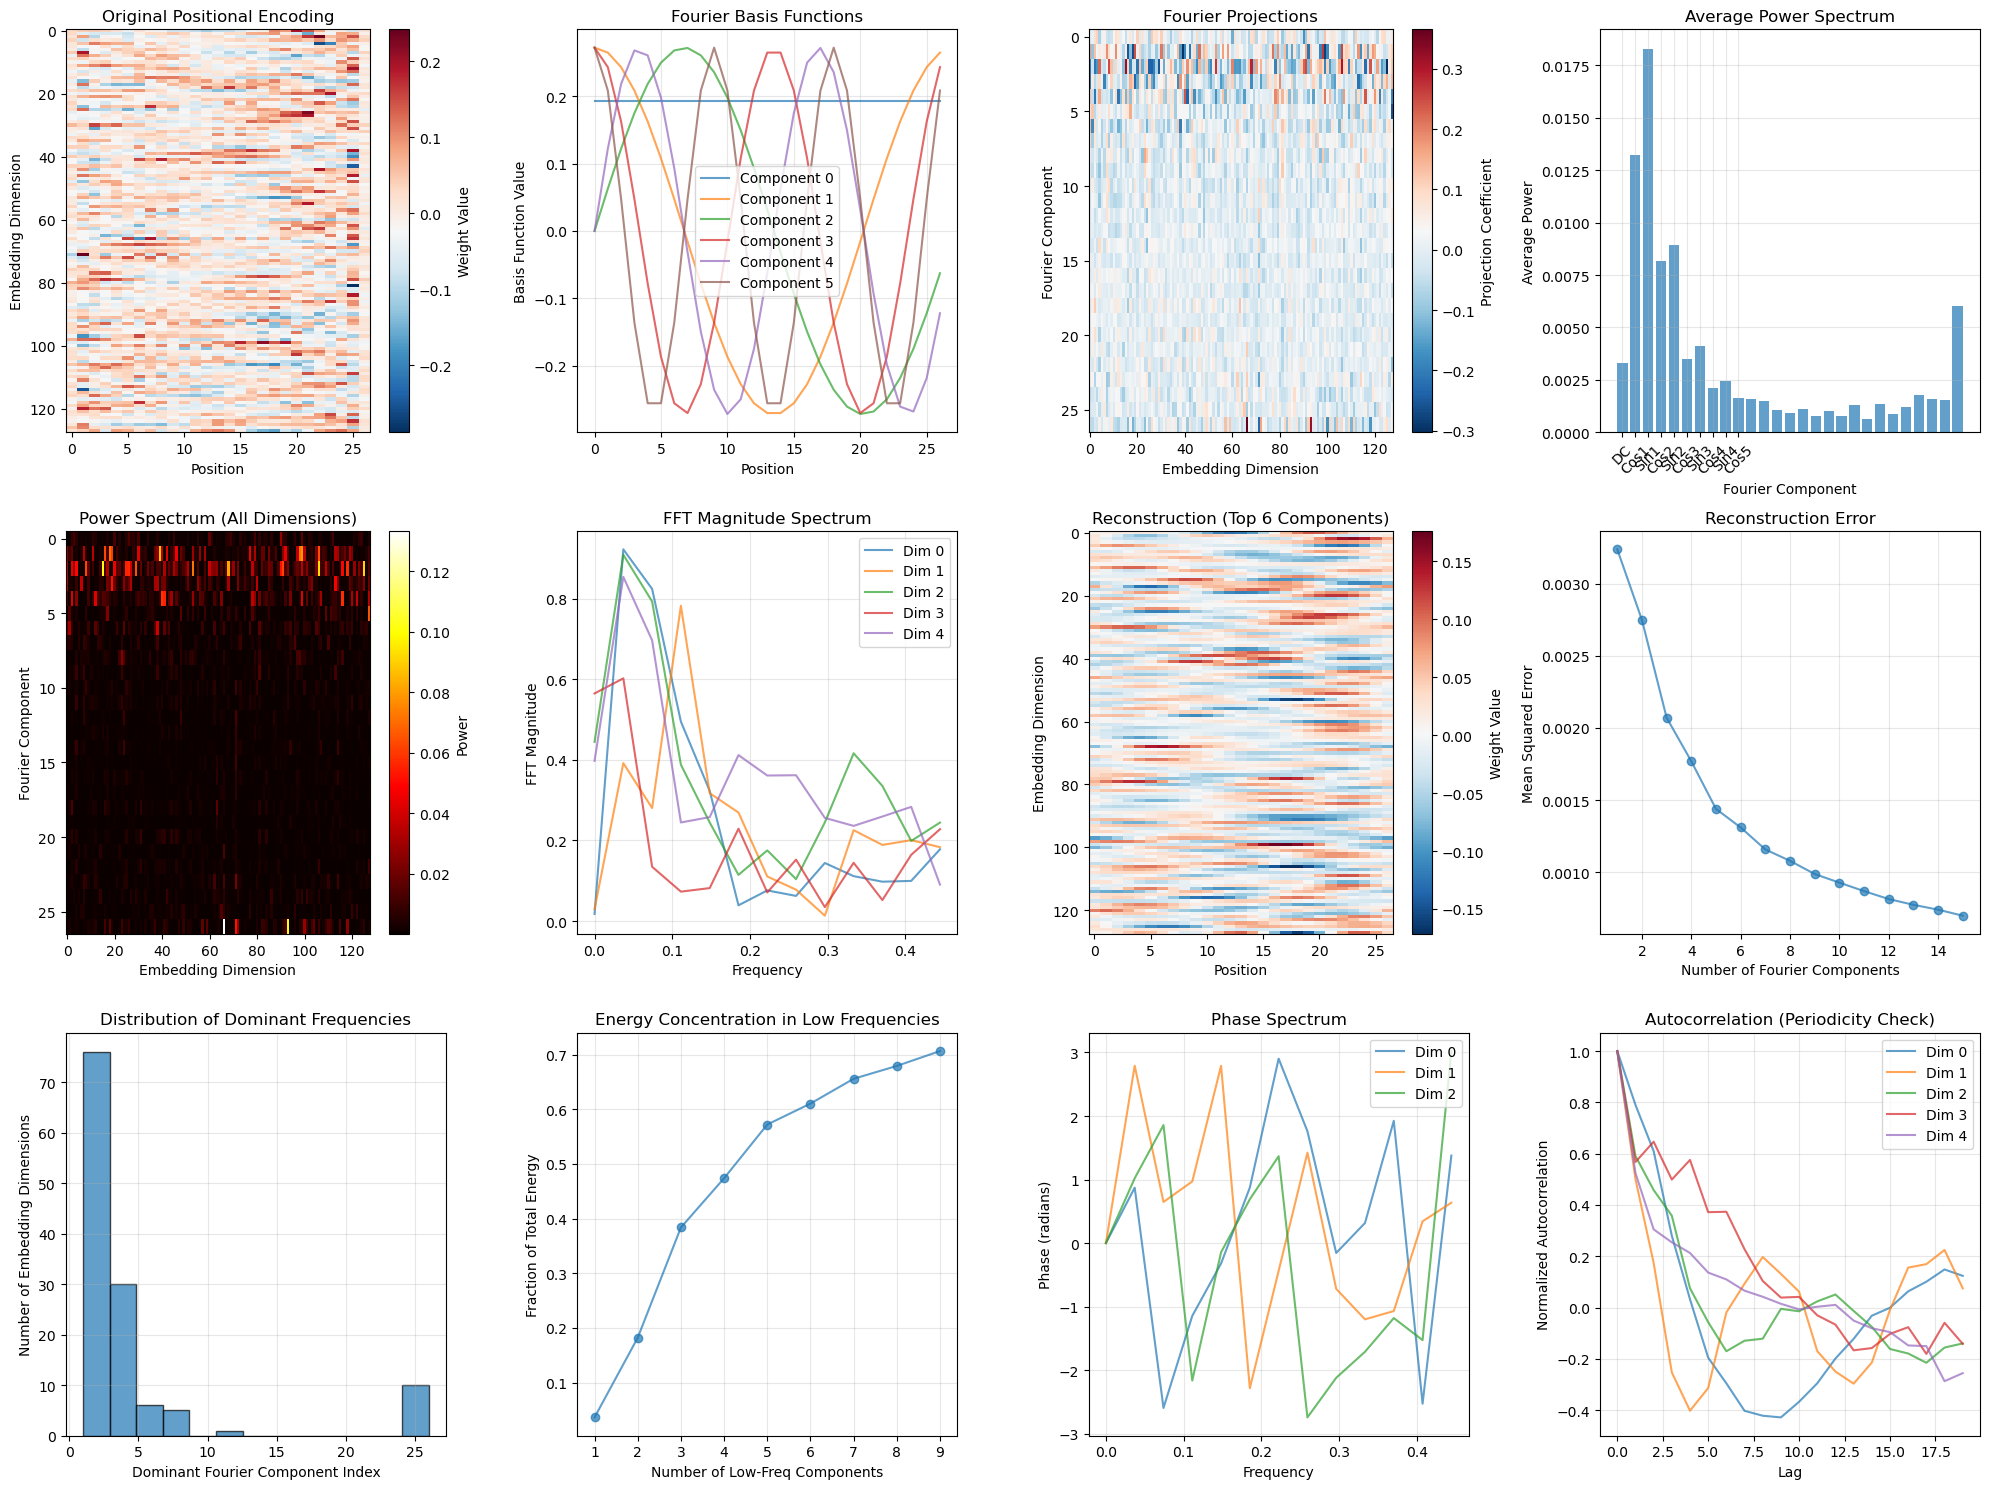


Fourier Analysis Summary:
  Shape: (27, 128)
  Number of Fourier components: 27
  DC component average: 0.0108
  DC component std: 0.0565

Top 5 most periodic embedding dimensions: [125  15  93 106  66]
Their periodic strength scores: [0.01772468 0.01938138 0.01990894 0.02065099 0.02534989]

Energy distribution:
  DC component energy: 3.64%
  Low frequency (first 5) energy: 57.21%
  High frequency energy: 42.79%

Dominant frequency analysis:
  Most common dominant frequency component: 2
  Number of dimensions with this frequency: 47
  Frequency diversity (unique dominant freqs): 10

Comparison to sinusoidal patterns:
  Energy in sine/cosine components vs DC: 26.44
  Average reconstruction error with 6 components: 0.001310
  Relative reconstruction error: 39.00%


In [18]:
# Fourier basis projection of model.tgt_pos_encoding
import numpy as np
from scipy.fft import fft, fftfreq, fft2
from scipy.linalg import dft

# Extract positional encoding weights
pos_encoding_weights = model.tgt_pos_encoding.pe.weight.data.cpu().numpy()
n_positions, d_model = pos_encoding_weights.shape
print(f"Positional encoding shape: {pos_encoding_weights.shape}")

# Create Fourier basis functions
def create_fourier_basis(n_positions, n_components):
    """Create Fourier basis functions for projection"""
    basis = np.zeros((n_positions, n_components))
    
    # DC component
    basis[:, 0] = 1.0 / np.sqrt(n_positions)
    
    # Sine and cosine components
    for k in range(1, n_components // 2 + 1):
        if 2*k-1 < n_components:
            # Cosine component
            basis[:, 2*k-1] = np.sqrt(2/n_positions) * np.cos(2*np.pi*k*np.arange(n_positions)/n_positions)
        if 2*k < n_components:
            # Sine component  
            basis[:, 2*k] = np.sqrt(2/n_positions) * np.sin(2*np.pi*k*np.arange(n_positions)/n_positions)
    
    return basis

# Number of Fourier components to use
n_fourier_components = n_positions
fourier_basis = create_fourier_basis(n_positions, n_fourier_components)

# Project each embedding dimension onto Fourier basis
fourier_projections = np.dot(fourier_basis.T, pos_encoding_weights)  # Shape: (n_fourier_components, d_model)

# Compute power spectrum for each embedding dimension
power_spectra = fourier_projections ** 2

# Average power spectrum across all embedding dimensions
avg_power_spectrum = np.mean(power_spectra, axis=1)

# Also compute FFT for each embedding dimension
fft_results = np.abs(fft(pos_encoding_weights, axis=0))
frequencies = fftfreq(n_positions, 1.0)

# Create comprehensive visualization
plt.figure(figsize=(20, 15))

# Plot 1: Original positional encoding heatmap
plt.subplot(3, 4, 1)
im = plt.imshow(pos_encoding_weights.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, label='Weight Value')
plt.xlabel('Position')
plt.ylabel('Embedding Dimension')
plt.title('Original Positional Encoding')

# Plot 2: Fourier basis functions (first few)
plt.subplot(3, 4, 2)
for i in range(min(6, n_fourier_components)):
    plt.plot(fourier_basis[:, i], label=f'Component {i}', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Basis Function Value')
plt.title('Fourier Basis Functions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Fourier projections heatmap
plt.subplot(3, 4, 3)
im = plt.imshow(fourier_projections, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, label='Projection Coefficient')
plt.xlabel('Embedding Dimension')
plt.ylabel('Fourier Component')
plt.title('Fourier Projections')

# Plot 4: Average power spectrum
plt.subplot(3, 4, 4)
component_labels = ['DC'] + [f'Cos{i//2+1}' if i%2==1 else f'Sin{i//2}' for i in range(1, len(avg_power_spectrum))]
plt.bar(range(len(avg_power_spectrum)), avg_power_spectrum, alpha=0.7)
plt.xlabel('Fourier Component')
plt.ylabel('Average Power')
plt.title('Average Power Spectrum')
plt.xticks(range(min(10, len(component_labels))), component_labels[:min(10, len(component_labels))], rotation=45)
plt.grid(True, alpha=0.3)

# Plot 5: Power spectrum for each embedding dimension
plt.subplot(3, 4, 5)
im = plt.imshow(power_spectra, aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(im, label='Power')
plt.xlabel('Embedding Dimension')
plt.ylabel('Fourier Component')
plt.title('Power Spectrum (All Dimensions)')

# Plot 6: FFT magnitude spectrum (first few dims)
plt.subplot(3, 4, 6)
for i in range(min(5, d_model)):
    plt.plot(frequencies[:n_positions//2], fft_results[:n_positions//2, i], 
             label=f'Dim {i}', alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('FFT Magnitude')
plt.title('FFT Magnitude Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 7: Reconstruction using top Fourier components
plt.subplot(3, 4, 7)
n_recon_components = min(6, n_fourier_components)
reconstructed = np.dot(fourier_basis[:, :n_recon_components], fourier_projections[:n_recon_components, :])
im = plt.imshow(reconstructed.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, label='Weight Value')
plt.xlabel('Position')
plt.ylabel('Embedding Dimension')
plt.title(f'Reconstruction (Top {n_recon_components} Components)')

# Plot 8: Reconstruction error
plt.subplot(3, 4, 8)
reconstruction_errors = []
component_counts = range(1, min(n_fourier_components, 15) + 1)
for n_comp in component_counts:
    recon = np.dot(fourier_basis[:, :n_comp], fourier_projections[:n_comp, :])
    error = np.mean((pos_encoding_weights - recon) ** 2)
    reconstruction_errors.append(error)

plt.plot(component_counts, reconstruction_errors, 'o-', alpha=0.7)
plt.xlabel('Number of Fourier Components')
plt.ylabel('Mean Squared Error')
plt.title('Reconstruction Error')
plt.grid(True, alpha=0.3)

# Plot 9: Dominant frequencies for each embedding dimension
plt.subplot(3, 4, 9)
dominant_freqs = []
for i in range(d_model):
    # Find the dominant frequency component (excluding DC)
    power_spectrum_dim = power_spectra[1:, i]  # Exclude DC component
    dominant_idx = np.argmax(power_spectrum_dim) + 1  # +1 because we excluded DC
    dominant_freqs.append(dominant_idx)

plt.hist(dominant_freqs, bins=n_fourier_components//2, alpha=0.7, edgecolor='black')
plt.xlabel('Dominant Fourier Component Index')
plt.ylabel('Number of Embedding Dimensions')
plt.title('Distribution of Dominant Frequencies')
plt.grid(True, alpha=0.3)

# Plot 10: Energy concentration
plt.subplot(3, 4, 10)
# Calculate what fraction of energy is in low-frequency components
low_freq_energy = []
for threshold in range(1, min(10, n_fourier_components)):
    energy_ratio = np.sum(power_spectra[:threshold, :]) / np.sum(power_spectra)
    low_freq_energy.append(energy_ratio)

plt.plot(range(1, len(low_freq_energy) + 1), low_freq_energy, 'o-', alpha=0.7)
plt.xlabel('Number of Low-Freq Components')
plt.ylabel('Fraction of Total Energy')
plt.title('Energy Concentration in Low Frequencies')
plt.grid(True, alpha=0.3)

# Plot 11: Phase analysis (for complex FFT)
plt.subplot(3, 4, 11)
complex_fft = fft(pos_encoding_weights, axis=0)
phases = np.angle(complex_fft)
# Plot phase for first few embedding dimensions
for i in range(min(3, d_model)):
    plt.plot(frequencies[:n_positions//2], phases[:n_positions//2, i], 
             label=f'Dim {i}', alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('Phase (radians)')
plt.title('Phase Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 12: Periodic pattern detection
plt.subplot(3, 4, 12)
# Check for periodicity by computing autocorrelation
autocorr_results = []
for i in range(min(5, d_model)):
    signal = pos_encoding_weights[:, i]
    autocorr = np.correlate(signal, signal, mode='full')
    autocorr = autocorr[autocorr.size // 2:]
    autocorr_results.append(autocorr / autocorr[0])  # Normalize

for i, autocorr in enumerate(autocorr_results):
    plt.plot(autocorr[:min(20, len(autocorr))], label=f'Dim {i}', alpha=0.7)
plt.xlabel('Lag')
plt.ylabel('Normalized Autocorrelation')
plt.title('Autocorrelation (Periodicity Check)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed analysis
print(f"\nFourier Analysis Summary:")
print(f"  Shape: {pos_encoding_weights.shape}")
print(f"  Number of Fourier components: {n_fourier_components}")
print(f"  DC component average: {np.mean(fourier_projections[0, :]):.4f}")
print(f"  DC component std: {np.std(fourier_projections[0, :]):.4f}")

# Find dimensions with strongest periodic patterns
periodic_strength = np.std(power_spectra[1:, :], axis=0)  # Exclude DC, measure variation in frequency domain
top_periodic_dims = np.argsort(periodic_strength)[-5:]
print(f"\nTop 5 most periodic embedding dimensions: {top_periodic_dims}")
print(f"Their periodic strength scores: {periodic_strength[top_periodic_dims]}")

# Energy distribution
total_energy = np.sum(power_spectra)
dc_energy = np.sum(power_spectra[0, :])
low_freq_energy_total = np.sum(power_spectra[:min(5, n_fourier_components), :])
print(f"\nEnergy distribution:")
print(f"  DC component energy: {dc_energy/total_energy:.2%}")
print(f"  Low frequency (first 5) energy: {low_freq_energy_total/total_energy:.2%}")
print(f"  High frequency energy: {(total_energy-low_freq_energy_total)/total_energy:.2%}")

# Dominant frequency analysis
print(f"\nDominant frequency analysis:")
print(f"  Most common dominant frequency component: {np.bincount(dominant_freqs).argmax()}")
print(f"  Number of dimensions with this frequency: {np.max(np.bincount(dominant_freqs))}")
print(f"  Frequency diversity (unique dominant freqs): {len(np.unique(dominant_freqs))}")

# Check if learned encodings resemble sinusoidal patterns
print(f"\nComparison to sinusoidal patterns:")
print(f"  Energy in sine/cosine components vs DC: {(total_energy-dc_energy)/dc_energy:.2f}")
print(f"  Average reconstruction error with 6 components: {reconstruction_errors[5]:.6f}")
print(f"  Relative reconstruction error: {reconstruction_errors[5]/np.var(pos_encoding_weights):.2%}")

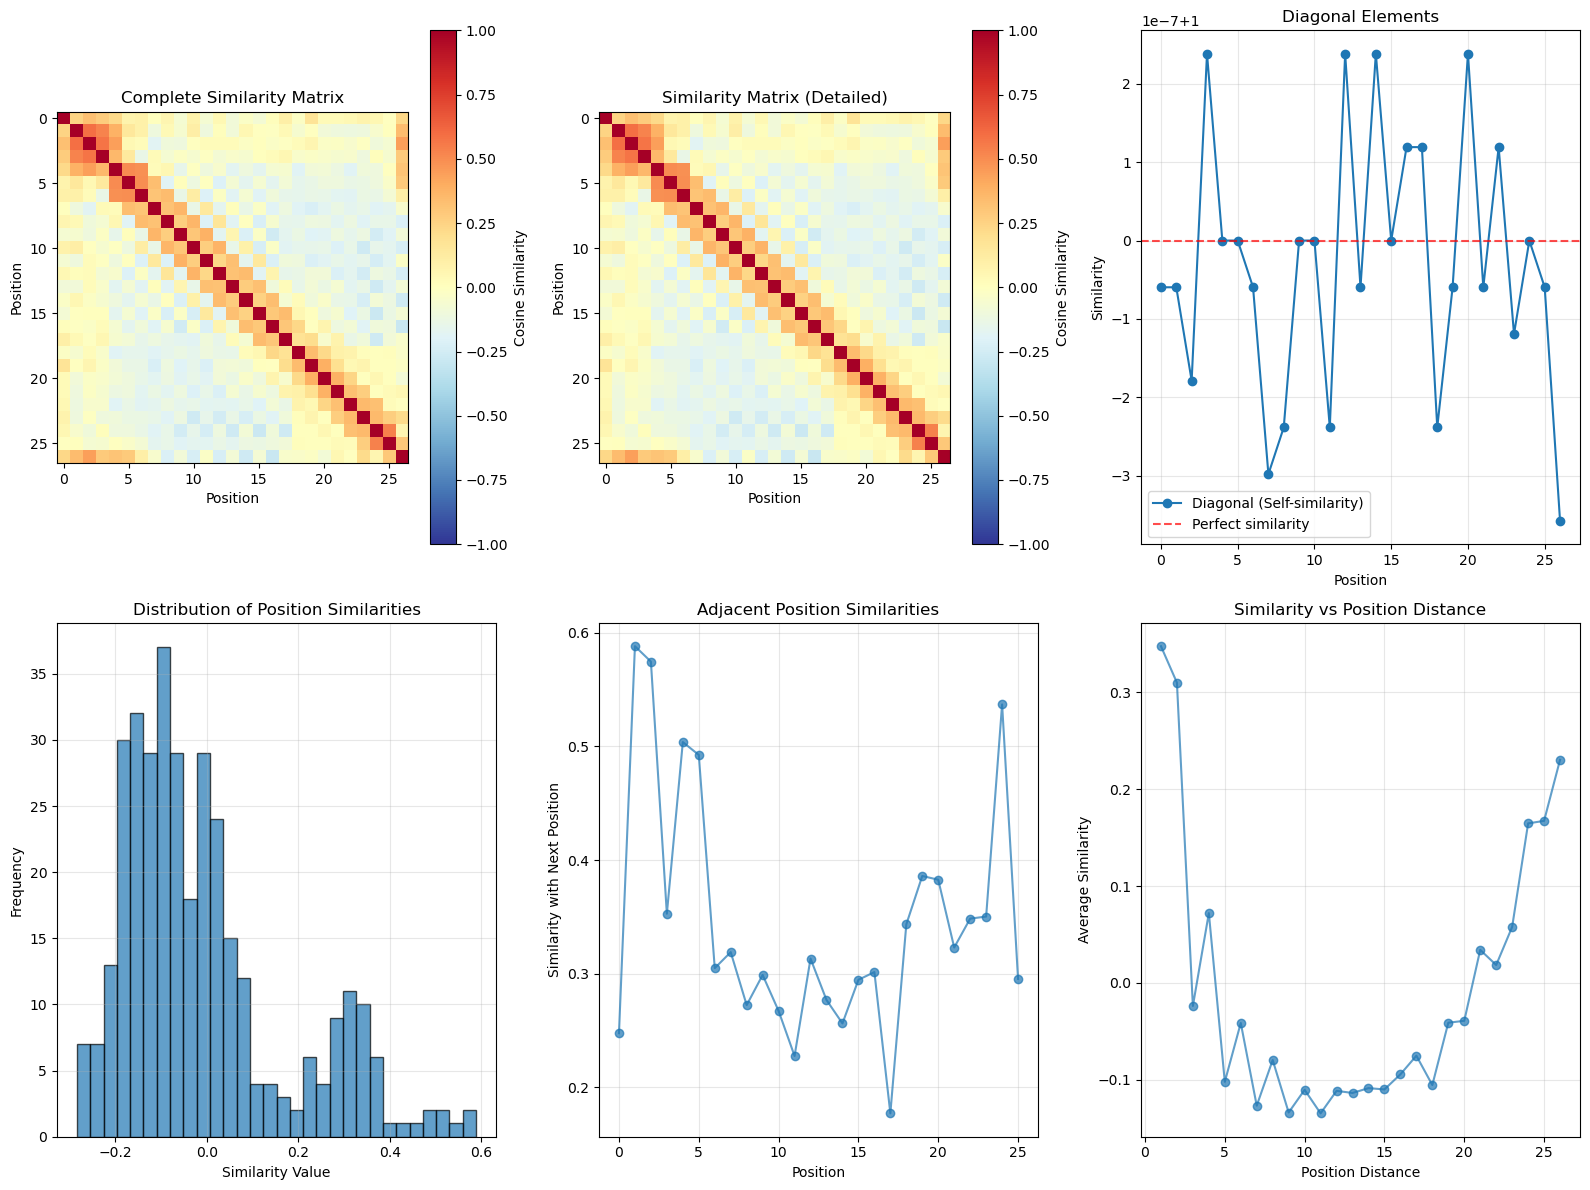

Positional Encoding Similarity Analysis:
  Shape: (27, 128)
  Similarity matrix shape: (27, 27)
  Average similarity (excluding diagonal): -0.0099
  Std of similarities: 0.1805
  Min similarity: -0.2836
  Max similarity: 0.5883
  Average adjacent similarity: 0.3475
  Most similar pair: positions (np.int64(1), np.int64(2)) with similarity 0.5883
  Least similar pair: positions (np.int64(16), np.int64(26)) with similarity -0.2836


In [19]:
# Extract positional encoding weights
pos_encoding_weights = model.src_pos_encoding.pe.weight.data.cpu().numpy()
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
similarity_matrix = cosine_similarity(pos_encoding_weights)

# Create comprehensive similarity analysis
plt.figure(figsize=(16, 12))

# Plot 1: Full similarity matrix
plt.subplot(2, 3, 1)
im1 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(im1, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Complete Similarity Matrix')

# Plot 2: Similarity matrix with annotations for small matrices
plt.subplot(2, 3, 2)
if similarity_matrix.shape[0] <= 20:  # Only annotate if matrix is small enough
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    # Add text annotations
    for i in range(similarity_matrix.shape[0]):
        for j in range(similarity_matrix.shape[1]):
            plt.text(j, i, f'{similarity_matrix[i, j]:.2f}', 
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(similarity_matrix[i, j]) > 0.5 else 'black')
    plt.colorbar(im2, label='Cosine Similarity')
else:
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    plt.colorbar(im2, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Similarity Matrix (Detailed)')

# Plot 3: Diagonal analysis (self-similarity should be 1)
plt.subplot(2, 3, 3)
diagonal = np.diag(similarity_matrix)
plt.plot(diagonal, 'o-', label='Diagonal (Self-similarity)')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Perfect similarity')
plt.xlabel('Position')
plt.ylabel('Similarity')
plt.title('Diagonal Elements')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Off-diagonal similarities
plt.subplot(2, 3, 4)
# Extract upper triangle (excluding diagonal)
upper_triangle = similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)]
plt.hist(upper_triangle, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Similarity Value')
plt.ylabel('Frequency')
plt.title('Distribution of Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 5: Adjacent position similarities
plt.subplot(2, 3, 5)
adjacent_similarities = [similarity_matrix[i, i+1] for i in range(len(similarity_matrix)-1)]
plt.plot(adjacent_similarities, 'o-', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Similarity with Next Position')
plt.title('Adjacent Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 6: Distance-based similarity analysis
plt.subplot(2, 3, 6)
distances = []
similarities = []
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        distance = abs(i - j)
        similarity = similarity_matrix[i, j]
        distances.append(distance)
        similarities.append(similarity)

# Group by distance and compute mean similarity
unique_distances = sorted(set(distances))
mean_similarities = []
for d in unique_distances:
    sims_at_distance = [similarities[k] for k, dist in enumerate(distances) if dist == d]
    mean_similarities.append(np.mean(sims_at_distance))

plt.plot(unique_distances, mean_similarities, 'o-', alpha=0.7)
plt.xlabel('Position Distance')
plt.ylabel('Average Similarity')
plt.title('Similarity vs Position Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Positional Encoding Similarity Analysis:")
print(f"  Shape: {pos_encoding_weights.shape}")
print(f"  Similarity matrix shape: {similarity_matrix.shape}")
print(f"  Average similarity (excluding diagonal): {np.mean(upper_triangle):.4f}")
print(f"  Std of similarities: {np.std(upper_triangle):.4f}")
print(f"  Min similarity: {np.min(upper_triangle):.4f}")
print(f"  Max similarity: {np.max(upper_triangle):.4f}")
print(f"  Average adjacent similarity: {np.mean(adjacent_similarities):.4f}")
print(f"  Most similar pair: positions {np.unravel_index(np.argmax(similarity_matrix - np.eye(len(similarity_matrix))), similarity_matrix.shape)} with similarity {np.max(similarity_matrix - np.eye(len(similarity_matrix))):.4f}")
print(f"  Least similar pair: positions {np.unravel_index(np.argmin(similarity_matrix), similarity_matrix.shape)} with similarity {np.min(similarity_matrix):.4f}")

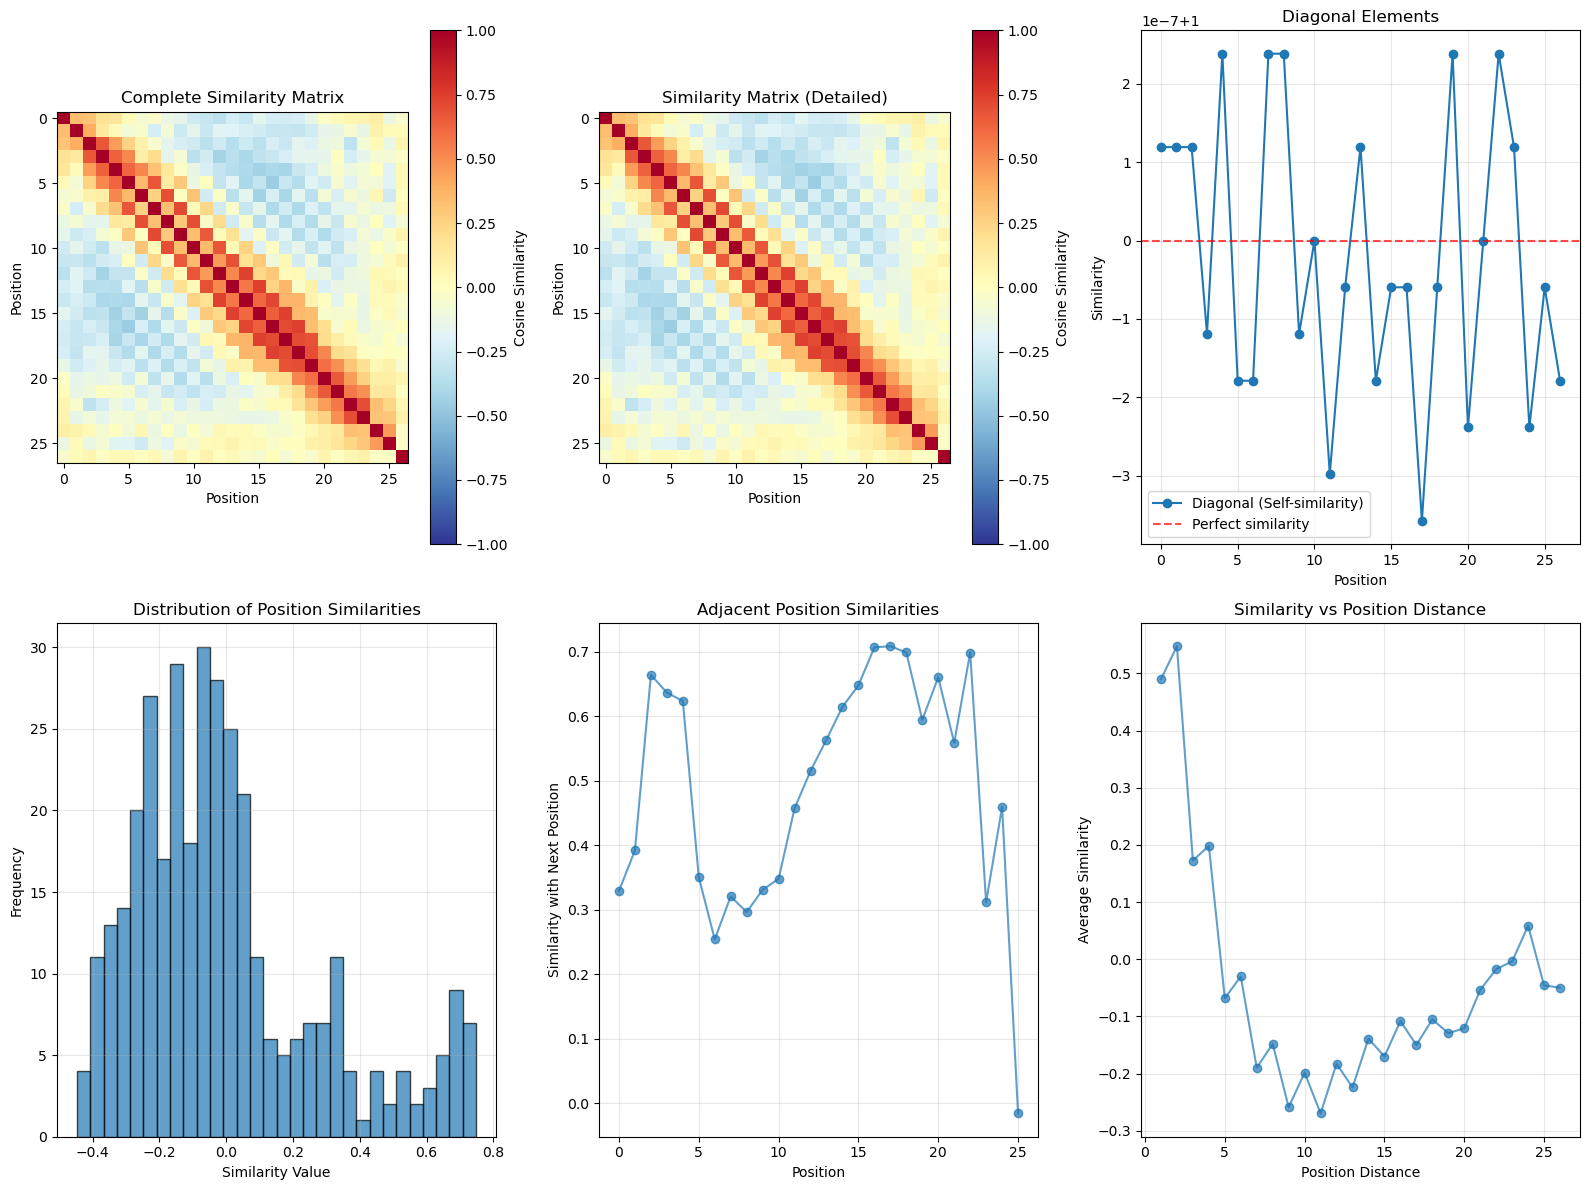

Positional Encoding Similarity Analysis:
  Shape: (27, 128)
  Similarity matrix shape: (27, 27)
  Average similarity (excluding diagonal): -0.0045
  Std of similarities: 0.2805
  Min similarity: -0.4465
  Max similarity: 0.7481
  Average adjacent similarity: 0.4897
  Most similar pair: positions (np.int64(13), np.int64(15)) with similarity 0.7481
  Least similar pair: positions (np.int64(5), np.int64(16)) with similarity -0.4465


In [47]:
# Extract positional encoding weights
pos_encoding_weights = model.tgt_pos_encoding.pe.weight.data.cpu().numpy()
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
similarity_matrix = cosine_similarity(pos_encoding_weights)

# Create comprehensive similarity analysis
plt.figure(figsize=(16, 12))

# Plot 1: Full similarity matrix
plt.subplot(2, 3, 1)
im1 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(im1, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Complete Similarity Matrix')

# Plot 2: Similarity matrix with annotations for small matrices
plt.subplot(2, 3, 2)
if similarity_matrix.shape[0] <= 20:  # Only annotate if matrix is small enough
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    # Add text annotations
    for i in range(similarity_matrix.shape[0]):
        for j in range(similarity_matrix.shape[1]):
            plt.text(j, i, f'{similarity_matrix[i, j]:.2f}', 
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(similarity_matrix[i, j]) > 0.5 else 'black')
    plt.colorbar(im2, label='Cosine Similarity')
else:
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    plt.colorbar(im2, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Similarity Matrix (Detailed)')

# Plot 3: Diagonal analysis (self-similarity should be 1)
plt.subplot(2, 3, 3)
diagonal = np.diag(similarity_matrix)
plt.plot(diagonal, 'o-', label='Diagonal (Self-similarity)')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Perfect similarity')
plt.xlabel('Position')
plt.ylabel('Similarity')
plt.title('Diagonal Elements')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Off-diagonal similarities
plt.subplot(2, 3, 4)
# Extract upper triangle (excluding diagonal)
upper_triangle = similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)]
plt.hist(upper_triangle, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Similarity Value')
plt.ylabel('Frequency')
plt.title('Distribution of Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 5: Adjacent position similarities
plt.subplot(2, 3, 5)
adjacent_similarities = [similarity_matrix[i, i+1] for i in range(len(similarity_matrix)-1)]
plt.plot(adjacent_similarities, 'o-', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Similarity with Next Position')
plt.title('Adjacent Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 6: Distance-based similarity analysis
plt.subplot(2, 3, 6)
distances = []
similarities = []
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        distance = abs(i - j)
        similarity = similarity_matrix[i, j]
        distances.append(distance)
        similarities.append(similarity)

# Group by distance and compute mean similarity
unique_distances = sorted(set(distances))
mean_similarities = []
for d in unique_distances:
    sims_at_distance = [similarities[k] for k, dist in enumerate(distances) if dist == d]
    mean_similarities.append(np.mean(sims_at_distance))

plt.plot(unique_distances, mean_similarities, 'o-', alpha=0.7)
plt.xlabel('Position Distance')
plt.ylabel('Average Similarity')
plt.title('Similarity vs Position Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Positional Encoding Similarity Analysis:")
print(f"  Shape: {pos_encoding_weights.shape}")
print(f"  Similarity matrix shape: {similarity_matrix.shape}")
print(f"  Average similarity (excluding diagonal): {np.mean(upper_triangle):.4f}")
print(f"  Std of similarities: {np.std(upper_triangle):.4f}")
print(f"  Min similarity: {np.min(upper_triangle):.4f}")
print(f"  Max similarity: {np.max(upper_triangle):.4f}")
print(f"  Average adjacent similarity: {np.mean(adjacent_similarities):.4f}")
print(f"  Most similar pair: positions {np.unravel_index(np.argmax(similarity_matrix - np.eye(len(similarity_matrix))), similarity_matrix.shape)} with similarity {np.max(similarity_matrix - np.eye(len(similarity_matrix))):.4f}")
print(f"  Least similar pair: positions {np.unravel_index(np.argmin(similarity_matrix), similarity_matrix.shape)} with similarity {np.min(similarity_matrix):.4f}")

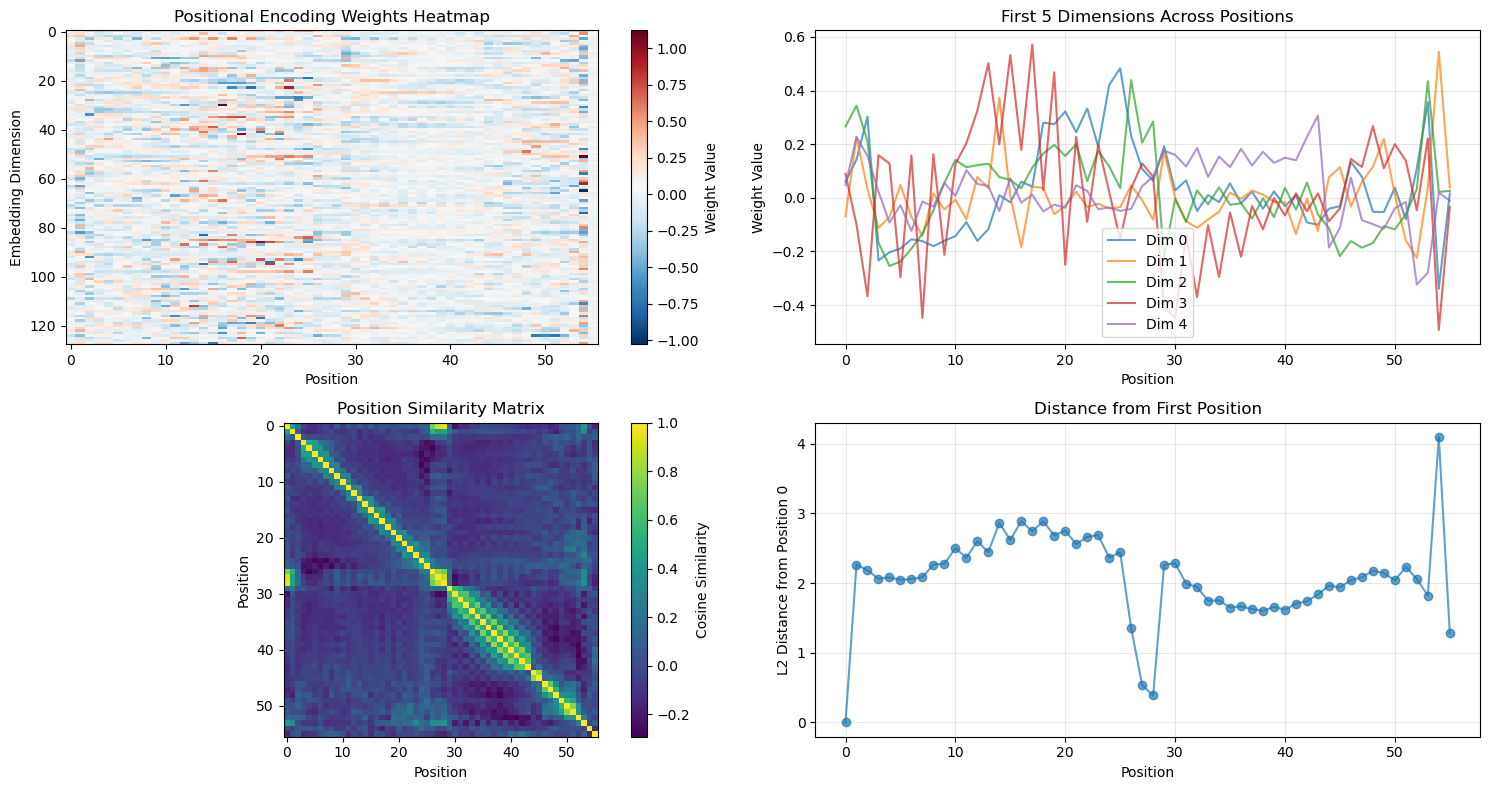

Position encoding statistics:
  Mean weight value: 0.0001
  Std weight value: 0.1658
  Min weight value: -1.0259
  Max weight value: 1.1209
  Average similarity between adjacent positions: 0.4019


In [ ]:
# # Additional analysis: Visualize the actual positional encoding weights
# plt.figure(figsize=(15, 8))

# # Plot 1: Heatmap of positional encoding weights
# plt.subplot(2, 2, 1)
# im = plt.imshow(pos_encoding_weights.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
# plt.colorbar(im, label='Weight Value')
# plt.xlabel('Position')
# plt.ylabel('Embedding Dimension')
# plt.title('Positional Encoding Weights Heatmap')

# # Plot 2: First few dimensions over positions
# plt.subplot(2, 2, 2)
# for i in range(min(5, pos_encoding_weights.shape[1])):
#     plt.plot(pos_encoding_weights[:, i], label=f'Dim {i}', alpha=0.7)
# plt.xlabel('Position')
# plt.ylabel('Weight Value')
# plt.title('First 5 Dimensions Across Positions')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Plot 3: Position similarities (cosine similarity matrix)
# plt.subplot(2, 2, 3)
# from sklearn.metrics.pairwise import cosine_similarity
# similarity_matrix = cosine_similarity(pos_encoding_weights)
# im = plt.imshow(similarity_matrix, cmap='viridis', interpolation='nearest')
# plt.colorbar(im, label='Cosine Similarity')
# plt.xlabel('Position')
# plt.ylabel('Position')
# plt.title('Position Similarity Matrix')

# # Plot 4: Distance from first position
# plt.subplot(2, 2, 4)
# distances = np.linalg.norm(pos_encoding_weights - pos_encoding_weights[0], axis=1)
# plt.plot(distances, 'o-', alpha=0.7)
# plt.xlabel('Position')
# plt.ylabel('L2 Distance from Position 0')
# plt.title('Distance from First Position')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print some statistics
# print(f"Position encoding statistics:")
# print(f"  Mean weight value: {pos_encoding_weights.mean():.4f}")
# print(f"  Std weight value: {pos_encoding_weights.std():.4f}")
# print(f"  Min weight value: {pos_encoding_weights.min():.4f}")
# print(f"  Max weight value: {pos_encoding_weights.max():.4f}")
# print(f"  Average similarity between adjacent positions: {np.mean([cosine_similarity([pos_encoding_weights[i]], [pos_encoding_weights[i+1]])[0,0] for i in range(len(pos_encoding_weights)-1)]):.4f}")